# 0. Packages

In [1]:
import numpy as np
import pandas as pd; pd.set_option("display.max_columns", 200)
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, accuracy_score, r2_score, roc_auc_score, f1_score, balanced_accuracy_score
import sklearn
import seaborn as sns
import gc

import os
from os.path import dirname, join as pathjoin
import scipy.io as sio

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from glob import glob
from tqdm import tqdm

from datetime import timedelta, date, datetime

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("../utils/")
from util_selector import format_time
# from util_preprocessing import *
from util_postprocessing import *
from util_models import *

# random_state=0
# # random_state=821

# np.random.seed(random_state)
# sklearn.random.seed(random_state)

In [2]:
def pivot_dataframe(df, scoring="f1_weighted"):
    return df.pivot(
        columns=['selection_algorithm'],
        index = [
            'dataset_name', 'model_name', 
            # 'include_lowest',
            # 'use_fix_range',
        ],
        values = ['test_{}'.format(scoring)],
    )

In [3]:
eval_metric_col_name = 'test_accuracy'

# A-0) All features

In [4]:
data_dir = pathjoin('.', 'inputs', 'datasets.mat', 'bio_data')
# data_dir = pathjoin('..', '..', 'datasets', 'bio_data')

check_or_create_directory(data_dir)
bio_datasets_list = glob(pathjoin(data_dir, "*.mat"))
bio_datasets_list = [filename.split("/")[-1].split(".")[0] for filename in bio_datasets_list ]
print(len(bio_datasets_list))
bio_datasets_list


Directory already exists: inputs/datasets.mat/bio_data
14


['leukemia',
 'TOX_171',
 'colon',
 'GLI_85',
 'SMK_CAN_187',
 'Carcinom',
 'Prostate_GE',
 'GLIOMA',
 'lymphoma',
 'CLL_SUB_111',
 'lung',
 'lung_discrete',
 'nci9',
 'ALLAML']

In [5]:
# All the features
df = pd.read_csv('./outputs/dataframes/all_features-all_datasets.csv')
df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
print(df["model_name"].nunique())
for model_name in df["model_name"].unique():
    df_new = df[df["model_name"]==model_name]
    print(df_new.shape)
    display(df_new)

# df

6
(14, 10)


,fit_time,fit_time_std,score_time,score_time_std,test_score,test_score_std,train_score,train_score_std,model_name,dataset_name
0,0.0665,0.0276,0.1360,0.0731,77.27,6.78,86.20,3.46,KNeighbors,ALLAML
6,0.1162,0.0446,0.0782,0.0267,55.29,8.75,71.43,5.54,KNeighbors,CLL_SUB_111
12,0.2222,0.0662,0.1547,0.0560,79.25,4.45,85.04,1.76,KNeighbors,Carcinom
18,0.1011,0.0618,0.0789,0.0365,78.00,7.73,82.29,3.24,KNeighbors,GLIOMA
24,0.3146,0.1056,0.2679,0.0923,80.38,4.95,89.32,4.23,KNeighbors,GLI_85
30,0.1104,0.0564,0.0983,0.0537,78.06,7.87,90.14,1.88,KNeighbors,Prostate_GE
36,0.4338,0.2111,0.2854,0.0551,66.67,5.67,78.08,3.74,KNeighbors,SMK_CAN_187
42,0.4505,0.2707,0.3110,0.1191,70.96,6.44,86.13,2.72,KNeighbors,TOX_171
48,0.0569,0.0514,0.0530,0.0323,78.42,5.23,85.12,4.13,KNeighbors,colon
54,0.0634,0.0144,0.0565,0.0169,88.18,5.34,91.80,3.05,KNeighbors,leukemia


(14, 10)


,fit_time,fit_time_std,score_time,score_time_std,test_score,test_score_std,train_score,train_score_std,model_name,dataset_name
1,0.0473,0.0114,0.0273,0.0113,84.55,6.84,100.0,0.0,LinearSVC,ALLAML
7,0.2636,0.0441,0.0379,0.0121,67.06,4.96,100.0,0.0,LinearSVC,CLL_SUB_111
13,5.4206,3.1698,0.0344,0.0097,95.47,2.39,100.0,0.0,LinearSVC,Carcinom
19,0.0944,0.0180,0.0187,0.0066,64.00,12.25,100.0,0.0,LinearSVC,GLIOMA
25,0.2173,0.0559,0.0744,0.0131,61.15,3.82,100.0,0.0,LinearSVC,GLI_85
31,0.1664,0.0404,0.0339,0.0121,89.68,3.33,100.0,0.0,LinearSVC,Prostate_GE
37,0.4981,0.0446,0.0563,0.0067,70.00,4.78,100.0,0.0,LinearSVC,SMK_CAN_187
43,0.4355,0.0617,0.0556,0.0632,91.15,3.53,100.0,0.0,LinearSVC,TOX_171
49,0.0330,0.0064,0.0077,0.0023,70.53,6.18,100.0,0.0,LinearSVC,colon
55,0.0548,0.0234,0.0282,0.0065,80.91,7.67,100.0,0.0,LinearSVC,leukemia


(14, 10)


...

,fit_time,fit_time_std,score_time,score_time_std,test_score,test_score_std,train_score,train_score_std,model_name,dataset_name
3,2.9262,0.5941,0.9889,0.2463,93.64,6.14,100.0,0.0,XGB,ALLAML
9,15.4810,5.3447,2.0121,0.6791,73.82,8.14,100.0,0.0,XGB,CLL_SUB_111
15,33.0978,10.4246,4.4117,1.9454,85.66,4.10,100.0,0.0,XGB,Carcinom
21,6.5839,1.8648,3.7588,1.7552,64.67,11.78,100.0,0.0,XGB,GLIOMA
27,18.1587,5.3881,5.4652,0.2719,81.92,5.75,100.0,0.0,XGB,GLI_85
33,4.5012,1.3130,2.2582,0.8931,88.71,4.87,100.0,0.0,XGB,Prostate_GE
39,90.6788,34.9319,7.0663,2.8925,67.54,3.43,100.0,0.0,XGB,SMK_CAN_187
45,20.2085,6.4659,2.2095,0.6945,74.04,7.21,100.0,0.0,XGB,TOX_171
51,0.9974,0.1465,0.5186,0.2747,78.95,6.56,100.0,0.0,XGB,colon
57,3.7009,0.9764,1.6535,0.5070,97.73,2.40,100.0,0.0,XGB,leukemia


(14, 10)


,fit_time,fit_time_std,score_time,score_time_std,test_score,test_score_std,train_score,train_score_std,model_name,dataset_name
4,0.4977,0.0768,0.0493,0.0275,83.18,8.58,100.00,0.00,MLP,ALLAML
10,0.6605,0.1140,0.0468,0.0213,63.24,5.05,100.00,0.00,MLP,CLL_SUB_111
16,1.2885,0.6047,0.0623,0.0304,89.25,4.18,100.00,0.00,MLP,Carcinom
22,0.6765,0.3231,0.0214,0.0097,66.67,9.94,100.00,0.00,MLP,GLIOMA
28,2.2686,0.4719,0.1507,0.0704,77.69,5.06,100.00,0.00,MLP,GLI_85
34,1.8667,1.0620,0.0648,0.0338,83.55,6.53,100.00,0.00,MLP,Prostate_GE
40,6.6386,5.8062,0.1247,0.0375,67.54,4.84,98.92,3.41,MLP,SMK_CAN_187
46,0.7973,0.1481,0.0361,0.0165,84.23,5.72,100.00,0.00,MLP,TOX_171
52,0.2917,0.0646,0.0140,0.0126,81.05,5.08,100.00,0.00,MLP,colon
58,0.7118,0.4265,0.0462,0.0276,89.09,6.14,100.00,0.00,MLP,leukemia


(14, 10)


,fit_time,fit_time_std,score_time,score_time_std,test_score,test_score_std,train_score,train_score_std,model_name,dataset_name
5,0.0216,0.0073,0.0186,0.0049,95.91,4.52,100.00,0.00,GaussianNB,ALLAML
11,0.0577,0.0234,0.0625,0.0475,63.24,8.23,96.75,2.14,GaussianNB,CLL_SUB_111
17,0.0402,0.0126,0.0438,0.0146,74.91,4.36,100.00,0.00,GaussianNB,Carcinom
23,0.0131,0.0035,0.0160,0.0083,30.67,7.17,100.00,0.00,GaussianNB,GLIOMA
29,0.0683,0.0197,0.0611,0.0298,80.00,7.86,96.61,1.79,GaussianNB,GLI_85
35,0.0327,0.0135,0.0241,0.0057,60.32,10.32,89.72,3.70,GaussianNB,Prostate_GE
41,0.1310,0.0806,0.0729,0.0209,63.16,6.30,71.38,2.11,GaussianNB,SMK_CAN_187
47,0.0247,0.0090,0.0190,0.0052,75.38,7.57,96.39,1.38,GaussianNB,TOX_171
53,0.0122,0.0068,0.0095,0.0075,68.95,15.18,88.37,7.44,GaussianNB,colon
59,0.0308,0.0184,0.0186,0.0038,79.09,6.50,99.20,1.03,GaussianNB,leukemia


In [6]:
df_all_agg = df.groupby(["dataset_name"]).agg({"test_score":np.max}).reset_index().merge(
    df.groupby(["dataset_name"]).agg({"test_score":np.mean}).reset_index().rename(columns={"test_score":"test_accuracy"}).merge(
        df.groupby(["dataset_name"]).agg({"test_score":np.std}).reset_index().rename(columns={"test_score":"test_accuracy_std"})
    )
)

df_all_agg.to_csv("./outputs/dataframes/all_features-best_overall.csv", index=False)


In [7]:
df_all_mean = df.groupby(["dataset_name"]).agg({"test_score":np.mean}).reset_index().rename(columns={"test_score":"test_accuracy"})
df_all_std = df.groupby(["dataset_name"]).agg({"test_score":np.std}).reset_index().rename(columns={"test_score":"test_accuracy"})

upgrade_aggregated_results_presentation(df_all_mean, df_all_std).to_csv("./outputs/dataframes/all_features-avg_best_overall.csv", index=False)

# A) Extracting and saving best configs

In [8]:
# !pwd

In [9]:
!ls './outputs/dataframes/'

all_features-all_datasets.csv      FS_P1.0S-Standardizer-accuracy-5CV
all_features-avg_best_overall.csv  FS_P1.3-Standardizer-accuracy-5CV
all_features-best_overall.csv      FS_P1.3S-Standardizer-accuracy-5CV
FS_P0.1-Standardizer-accuracy-5CV  FS_P1.5-Standardizer-accuracy-5CV
FS_P0.1S-Standardizer-accuracy-5CV FS_P1.5S-Standardizer-accuracy-5CV
FS_P0.3-Standardizer-accuracy-5CV  FS_P1.7-Standardizer-accuracy-5CV
FS_P0.3S-Standardizer-accuracy-5CV FS_P1.7S-Standardizer-accuracy-5CV
FS_P0.5-Standardizer-accuracy-5CV  FS_P2.0-Standardizer-accuracy-5CV
FS_P0.5S-Standardizer-accuracy-5CV FS_P2.0S-Standardizer-accuracy-5CV
FS_P0.7-Standardizer-accuracy-5CV  FS-Standardizer-accuracy-5CV
FS_P0.7S-Standardizer-accuracy-5CV Readme.md
FS_P1.0-Standardizer-accuracy-5CV


In [10]:
output_dir_list = [
    pathjoin('.', 'outputs', 'dataframes', 'FS-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.7-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.3-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.5-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.5-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.3-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.7-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.1-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P2.0-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.7S-Standardizer-accuracy-5CV'), # smoothed
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.3S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.5S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.5S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.3S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.7S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P0.1S-Standardizer-accuracy-5CV'), 
    pathjoin('.', 'outputs', 'dataframes', 'FS_P2.0S-Standardizer-accuracy-5CV'),
    pathjoin('.', 'outputs', 'dataframes', 'FS_P1.0-Standardizer-accuracy-5CV'), 
    # pathjoin('.', 'outputs', 'dataframes', 'FS_P1.0S-Standardizer-accuracy-5CV'),
]


In [11]:
for output_dir in output_dir_list:
    extract_and_save_best_config_per_model(output_dir=output_dir, metric_col_name = eval_metric_col_name )

Directory already exists: outputs/dataframes/FS-Standardizer-accuracy-5CV/best_configs


100%|██████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 18.13it/s]


Directory already exists: outputs/dataframes/FS_P0.7-Standardizer-accuracy-5CV/best_configs


100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.26it/s]


Directory already exists: outputs/dataframes/FS_P1.3-Standardizer-accuracy-5CV/best_configs


...

100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.56it/s]


Directory already exists: outputs/dataframes/FS_P2.0S-Standardizer-accuracy-5CV/best_configs


100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.73it/s]


Directory already exists: outputs/dataframes/FS_P1.0-Standardizer-accuracy-5CV/best_configs


100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.75it/s]


# B) Best config per valuation method, selection algo, and per model

In [12]:
# output_dir = pathjoin('.', 'outputs', 'dataframes', 'FS-Standardizer-accuracy-5CV')
output_dir = pathjoin('.', 'outputs', 'dataframes', 'FS_P0.7-Standardizer-accuracy-5CV')

# output_dfs_list = glob(pathjoin(output_dir,"cosine_sim-*.csv"))
output_dfs_list = glob(pathjoin(output_dir,"*.csv"))

# output_dfs_list.reverse() # Just want bio_data first
print(len(output_dfs_list))
# output_dfs_list

84


In [13]:
valuation_method_list = set([filename.split("/")[-1].split("-")[0]  for filename in output_dfs_list])
selection_method_list = set([filename.split("/")[-1].split("-")[1]  for filename in output_dfs_list])

valuation_method_list, selection_method_list

({'Fvalue', 'gini', 'mutual_info'}, {'KGroups_max', 'KGroups_max++'})

In [14]:
kgroups_variants_dirs = glob(pathjoin('.', 'outputs', 'dataframes', 'FS_P*-Standardizer-accuracy-5CV','best_configs'))
# kgroups_variants_dirs += [pathjoin('.', 'outputs', 'dataframes', 'FS-Standardizer-accuracy-5CV','best_configs')]

# kgroups_variants_dirs = glob(pathjoin('.', 'outputs', 'dataframes', 'FS*-Standardizer-accuracy-5CV','best_configs'))

kgroups_variants_dirs.sort()

output_dfs_list = glob(pathjoin(kgroups_variants_dirs[1],"*.csv"))
# output_dfs_list

valuation_method_list = set([filename.split("/")[-1].split("-")[0]  for filename in output_dfs_list])
selection_method_list = set([filename.split("/")[-1].split("-")[1]  for filename in output_dfs_list])
model_list = set([filename.split("/")[-1].split("-")[2].split(".")[0]  for filename in output_dfs_list])

print(" valuation_methods => {}\n selection_methods => {}\n ML models => {}".format(valuation_method_list, selection_method_list, model_list))

kgroups_variants_dirs

 valuation_methods => {'variance', 'gini', 'mutual_info', 'entropy', 'cosine_sim', 'Fvalue'}
 selection_methods => {'KGroups_max++', 'KGroups_max'}
 ML models => {'KNeighbors', 'RandomForest', 'LinearSVC', 'GaussianNB', 'XGB', 'MLP'}


['./outputs/dataframes/FS_P0.1-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.1S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.3-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.3S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.5-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.5S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.7-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P0.7S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.0-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.3-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.3S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.5-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.5S-Standardizer-accuracy-5CV/best_configs',
 './outputs/dataframes/FS_P1.7-Standardizer-accuracy-5CV/b

In [15]:
# model_name = 'LinearSVC'
# valuation_method = 'gini'
# selection_method = 'KGroups_max'
kgroups_variant_list = [
    'KGroups_max', 
    'KGroups_max++'
]

In [16]:
# kgroups_variants_dirs
# valuation_method_list
# model_list

In [17]:
saving_dir = "./outputs/extracted_results"
check_or_create_directory(saving_dir)

df_out = None
df_out_formatted = None 
df_out_exec_time = None

for valuation_method in valuation_method_list:
    for model_name in model_list:
        print("{} - {}".format(valuation_method, model_name))
        df_out_list = []
        df_out_formatted_list = [] 
        df_out_exec_time_list = []

        for kgroups_variant in kgroups_variant_list:
            ## Loading and formatting KGroups variants
            kgroups_variants_results_df_list = []
            kgroups_variants_formatted_results_df_list = []
            kgroups_variants_exec_time_df_list = []
            
            for dir_name in kgroups_variants_dirs:
                filename_list = glob(pathjoin(dir_name, "{}-{}-{}.csv".format(valuation_method, kgroups_variant, model_name)))
                # print(filename_list)
                
                variant_power = None
                if len(filename_list)<1:
                    pass
                elif filename_list[0] == filename_list[0].split("FS_P")[-1]:
                    variant_power = "1"
                else:
                    variant_power = filename_list[0].split("FS_P")[-1].split("-")[0]
                # print(filename_list)
                
                # print("KGroups variant power = {}".format(variant_power))
                
                dfs_list = []
                dfs_raw_list = []
                for filename in filename_list:
                    df = pd.read_csv(filename)
                    df_new = upgrade_results_presentation(
                       df.copy(), 
                        metric_col_name = eval_metric_col_name, 
                        num_desired_features_name = None
                    )
                    dfs_list += [df_new]
                    dfs_raw_list += [df]
                    
                # ## debugging
                # print("debugging=>", dir_name)
                # df_all = pd.concat(dfs_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1)
                # display(df_all)
                
                df_all = pd.concat(dfs_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1).pivot(
                        columns=['selection_algorithm'],
                        index = [
                            'dataset_name', #'model_name', 
                            # 'include_lowest',
                            # 'use_fix_range',
                        ],
                        values = [eval_metric_col_name],
                    )
                df_all = clean_up_dataframe(df_all)
                ## Renaming KGroups and KGroups++
                if kgroups_variant == 'KGroups_max++':
                    df_all.rename(columns={"KGroups_max++":"KGroups++ (P={})".format(variant_power)}, inplace=True)
                else:
                    df_all.rename(columns={"KGroups_max":"KGroups (P={})".format(variant_power)}, inplace=True)

                ## debugging
                # if df_all.shape[0] < 14:
                #     print("Problem with=>", dir_name)
                kgroups_variants_formatted_results_df_list += [df_all]
                
                df_all_exec_time = pd.concat(dfs_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1).pivot(
                        columns=['selection_algorithm'],
                        index = [
                            'dataset_name', #'model_name', 
                            # 'include_lowest',
                            # 'use_fix_range',
                        ],
                        values = ["CPU_time","Wall_time"],
                    )
                df_all_exec_time = clean_up_dataframe(df_all_exec_time, level_to_drop=1)
                ## Renaming KGroups and KGroups++ for exec time
                if kgroups_variant == 'KGroups_max++':
                    df_all_exec_time.rename(columns={
                        "CPU_time":"CPU_time++ (P={})".format(variant_power),
                        "Wall_time":"Wall_time++ (P={})".format(variant_power),
                        
                    }, inplace=True)
                else:
                    df_all_exec_time.rename(columns={
                        "CPU_time":"CPU_time (P={})".format(variant_power),
                        "Wall_time":"Wall_time (P={})".format(variant_power),
                        
                    }, inplace=True)
                    
                kgroups_variants_exec_time_df_list += [df_all_exec_time]
                
                df_raw_all = pd.concat(dfs_raw_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1).pivot(
                        columns=['selection_algorithm'],
                        index = [
                            'dataset_name', #'model_name', 
                            # 'include_lowest',
                            # 'use_fix_range',
                        ],
                        values = [eval_metric_col_name],
                    )
                
                df_raw_all = clean_up_dataframe(df_raw_all)
                ## Renaming KGroups and KGroups++
                if kgroups_variant == 'KGroups_max++':
                    df_raw_all.rename(columns={"KGroups_max++":"KGroups++ (P={})".format(variant_power)}, inplace=True)
                else:
                    df_raw_all.rename(columns={"KGroups_max":"KGroups (P={})".format(variant_power)}, inplace=True)
                    
                # df_raw_all.rename(columns={"KGroups_max":"KGroups_max (P={})".format(variant_power)}, inplace=True)
                kgroups_variants_results_df_list += [df_raw_all]
            
            ## Merging KGroups variants into one dataframe
            df_out = kgroups_variants_results_df_list[0]
            df_out_formatted = kgroups_variants_formatted_results_df_list[0]
            df_out_exec_time = kgroups_variants_exec_time_df_list[0]
            
            for i in range(1,len(kgroups_variants_formatted_results_df_list[1:])+1):
                df_out = df_out.merge(kgroups_variants_results_df_list[i], how="inner")
                df_out_formatted = df_out_formatted.merge(kgroups_variants_formatted_results_df_list[i], how="inner")
                df_out_exec_time = df_out_exec_time.merge(kgroups_variants_exec_time_df_list[i], how="inner")
                
            df_out_list += [df_out]
            df_out_formatted_list += [df_out_formatted]
            df_out_exec_time_list += [df_out_exec_time]

        if len(df_out_list) == 1:
            df_out = df_out_list[0]
            df_out_formatted = df_out_formatted_list[0]
            df_out_exec_time = df_out_exec_time_list[0]
        else:
            df_out = df_out_list[0].merge(df_out_list[1], how="inner")
            df_out_formatted = df_out_formatted_list[0].merge(df_out_formatted_list[1], how="inner")
            df_out_exec_time = df_out_exec_time_list[0].merge(df_out_exec_time_list[1], how="inner")
        gc.collect()
        
        ######################################### Competing methods #########################################
        ## Competing methods 
        output_dir = pathjoin('.', 'outputs', 'dataframes', 'FS-Standardizer-accuracy-5CV', 'best_configs')
        output_dfs_list = None
        if valuation_method == 'mutual_info':
            # output_dfs_list = glob(pathjoin(output_dir, f"mutual_info-KBest-{model_name}.csv")) + glob(pathjoin(output_dir,f"MI*-*-{model_name}.csv"))
            output_dfs_list = glob(pathjoin(output_dir, f"mutual_info-*-{model_name}.csv")) + glob(pathjoin(output_dir,f"MI*-*-{model_name}.csv"))
        elif  valuation_method == 'Fvalue':
            # output_dfs_list = glob(pathjoin(output_dir, f"Fvalue-KBest-{model_name}.csv")) + glob(pathjoin(output_dir,f"FC*-*-{model_name}.csv")) 
            output_dfs_list = glob(pathjoin(output_dir, f"Fvalue-*-{model_name}.csv")) + glob(pathjoin(output_dir,f"FC*-*-{model_name}.csv")) 
        elif  valuation_method == 'gini':
            # output_dfs_list = glob(pathjoin(output_dir, f"gini-KBest-{model_name}.csv")) + glob(pathjoin(output_dir,f"RFC*-*-{model_name}.csv")) 
            output_dfs_list = glob(pathjoin(output_dir, f"gini-*-{model_name}.csv")) + glob(pathjoin(output_dir,f"RFC*-*-{model_name}.csv")) 
        elif  valuation_method == 'cosine_sim':
            # output_dfs_list = glob(pathjoin(output_dir, f"cosine_sim-KBest-{model_name}.csv")) + glob(pathjoin(output_dir, f"cosine_sim-SCSIG*-{model_name}.csv"))
            output_dfs_list = glob(pathjoin(output_dir, f"cosine_sim-*-{model_name}.csv")) #+ glob(pathjoin(output_dir, f"cosine_sim-SCSIG*-{model_name}.csv"))
        else :
            output_dfs_list = glob(pathjoin(output_dir, f"{valuation_method}-KBest-{model_name}.csv")) #+ glob(pathjoin(output_dir,f"MI*-*-{model_name}.csv"))
        
        dfs_list = []
        dfs_raw_list = []
        
        for filename in output_dfs_list:
            df = pd.read_csv(filename)
            select_algo_name = df["selection_algorithm"].unique()[0]
            df_new = df.rename(columns={
                "CPU_time":"CPU_time ({})".format(select_algo_name),
                "Wall_time":"Wall_time ({})".format(select_algo_name),
            })
            
            df_new = upgrade_results_presentation(
                df_new, 
                metric_col_name = 'test_accuracy', 
                num_desired_features_name = None
            )
            dfs_list += [df_new]
            dfs_raw_list += [df]
        
        df_all = pd.concat(dfs_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1).pivot(
            columns=['selection_algorithm'],
            index = ['dataset_name'],
            values = [eval_metric_col_name],
        )
        df_all = clean_up_dataframe(df_all)
        
        cols_to_delete = [col for col in dfs_list[0].columns if "time" not in col.lower() and col != "dataset_name"]
        

        try:
            df_all_exec_time = dfs_list[0].drop(cols_to_delete, axis=1)
            for i in range(1,len(dfs_list[1:])+1):
                df_all_exec_time = df_all_exec_time.merge(dfs_list[i].drop(cols_to_delete, axis=1) , how="inner")
        except:
            print("cols_to_delete=>", cols_to_delete)
            del cols_to_delete[cols_to_delete.index("include_lowest")]
            print("cols_to_delete=>", cols_to_delete)
            df_all_exec_time = dfs_list[0].drop(cols_to_delete, axis=1)
            for i in range(1,len(dfs_list[1:])+1):
                df_all_exec_time = df_all_exec_time.merge(dfs_list[i].drop(cols_to_delete, axis=1) , how="inner")

            
        df_raw_all = pd.concat(dfs_raw_list).reset_index(drop=True).drop(["model_name", "valuation_method"],axis=1).pivot(
            columns=['selection_algorithm'],
            index = ['dataset_name'],
            values = [eval_metric_col_name],
        )
        df_raw_all = clean_up_dataframe(df_raw_all)

        ######################################### Combining results #########################################
        df_out = df_raw_all.merge(df_out, how="inner")
        df_out_formatted = df_all.merge(df_out_formatted, how="inner")
        df_out_exec_time = df_all_exec_time.merge(df_out_exec_time, how="inner")

        df_out.to_csv("{}/{}-{}-raw.csv".format(saving_dir, valuation_method, model_name), index=False)
        df_out_formatted.to_csv("{}/{}-{}-formatted.csv".format(saving_dir, valuation_method, model_name), index=False)
        df_out_exec_time.to_csv("{}/{}-{}-exec_time.csv".format(saving_dir, valuation_method, model_name), index=False)
        
        # display(
        #     df_out.head(),
        #     df_out_formatted.head(),
        #     df_out_exec_time.head(),
        # )

Directory already exists: outputs/extracted_results
variance - KNeighbors
variance - RandomForest
variance - LinearSVC
variance - GaussianNB
variance - XGB
variance - MLP
gini - KNeighbors
gini - RandomForest
gini - LinearSVC
gini - GaussianNB
gini - XGB
gini - MLP
mutual_info - KNeighbors
mutual_info - RandomForest
mutual_info - LinearSVC
mutual_info - GaussianNB
mutual_info - XGB
mutual_info - MLP
entropy - KNeighbors
entropy - RandomForest
entropy - LinearSVC
entropy - GaussianNB
entropy - XGB
entropy - MLP
cosine_sim - KNeighbors
cosine_sim - RandomForest
cosine_sim - LinearSVC
cols_to_delete=> ['num_desired_features', 'test_accuracy', 'model_name', 'selection_algorithm', 'valuation_method', 'include_lowest']
cols_to_delete=> ['num_desired_features', 'test_accuracy', 'model_name', 'selection_algorithm', 'valuation_method']
cosine_sim - GaussianNB
cosine_sim - XGB
cols_to_delete=> ['num_desired_features', 'test_accuracy', 'model_name', 'selection_algorithm', 'valuation_method', 'inc

In [18]:
valuation_method_list = [ 
    'mutual_info', 'gini', 'Fvalue',
]

kgroups_variant = 'KGroups_max' # 'KGroups_max' OR 'KGroups_max++'

In [19]:
# elapsed_time = "3 days, 7:42:08.862659"
elapsed_time = "0:39:33.526483"

# elapsed_time.split(" ")
(
    convert_duration_to_seconds("2 days, 7:17:26.830809")/convert_duration_to_seconds("0:04:37.353299"),
    convert_duration_to_seconds("3 days, 7:42:08.862659")/convert_duration_to_seconds("0:12:39.320045"),
    
)

(717.6652742533911, 377.8760542024179)

# C) Some aggregation of the results

In [20]:
# data_dir = pathjoin('.', 'inputs', 'datasets.mat', 'bio_data')
data_dir = pathjoin('..', '..', 'datasets', 'bio_data')

check_or_create_directory(data_dir)
bio_datasets_list = glob(pathjoin(data_dir, "*.mat"))
bio_datasets_list = [filename.split("/")[-1].split(".")[0] for filename in bio_datasets_list ]
print(len(bio_datasets_list))
bio_datasets_list

Directory already exists: ../../datasets/bio_data
14


['leukemia',
 'TOX_171',
 'colon',
 'GLI_85',
 'SMK_CAN_187',
 'Carcinom',
 'Prostate_GE',
 'GLIOMA',
 'lymphoma',
 'CLL_SUB_111',
 'lung',
 'lung_discrete',
 'nci9',
 'ALLAML']

In [25]:
# !pwd

In [26]:
saving_dir

'./outputs/extracted_results'

In [27]:
saving_dir = "./outputs/extracted_results"
output_dfs_list = glob(pathjoin(saving_dir, "*.csv"))
# output_dfs_list

valuation_method_list = set([filename.split("/")[-1].split("-")[0]  for filename in output_dfs_list])
model_list = set([filename.split("/")[-1].split("-")[1]  for filename in output_dfs_list])
# model_list = set([filename.split("/")[-1].split("-")[2].split(".")[0]  for filename in output_dfs_list])

# valuation_method_list = [ 
#     'mutual_info', 'gini', 'Fvalue',
# ]

valuation_method_list, model_list

({'Fvalue', 'gini', 'mutual_info'},
 {'GaussianNB', 'KNeighbors', 'LinearSVC', 'MLP', 'RandomForest', 'XGB'})

In [28]:
output_dfs_list

['./outputs/extracted_results/mutual_info-MLP-exec_time.csv',
 './outputs/extracted_results/gini-MLP-formatted.csv',
 './outputs/extracted_results/Fvalue-MLP-exec_time.csv',
 './outputs/extracted_results/gini-RandomForest-formatted.csv',
 './outputs/extracted_results/mutual_info-LinearSVC-formatted.csv',
 './outputs/extracted_results/Fvalue-MLP-raw.csv',
 './outputs/extracted_results/gini-GaussianNB-exec_time.csv',
 './outputs/extracted_results/Fvalue-KNeighbors-formatted.csv',
 './outputs/extracted_results/gini-XGB-raw.csv',
 './outputs/extracted_results/Fvalue-GaussianNB-raw.csv',
 './outputs/extracted_results/Fvalue-RandomForest-raw.csv',
 './outputs/extracted_results/mutual_info-GaussianNB-exec_time.csv',
 './outputs/extracted_results/mutual_info-KNeighbors-formatted.csv',
 './outputs/extracted_results/mutual_info-MLP-raw.csv',
 './outputs/extracted_results/Fvalue-RandomForest-exec_time.csv',
 './outputs/extracted_results/Fvalue-GaussianNB-exec_time.csv',
 './outputs/extracted_resu

In [29]:
# pd.DataFrame.replace("-", np.nan)
# pd.DataFrame.max

In [30]:
final_results_dir = pathjoin(saving_dir, "final")
check_or_create_directory(final_results_dir)

for valuation_method in valuation_method_list:
    df_max, df_mean, df_std = None, None, None 
    print("\nValuation method: {}".format(valuation_method))
    df_out = pd.DataFrame()
    ## Solution => concat + groupby dataset
    dfs_list = []
    for filename in glob(pathjoin(saving_dir, "{}-*-raw.csv".format(valuation_method))):
        print(filename)
        df = pd.read_csv(filename)
        df = df.replace("-", np.nan)
        for col in df.columns:
            if "mRMR" in col or "SCSIG" in col:
                df[col] = df[col].astype(float)
                        
        col_KG = [col for col in df.columns if "KGroups" == col.split(" ")[0]]
        col_KG_pplus = [col for col in df.columns if "KGroups++" == col.split(" ")[0]]
        col_mRMR = [col for col in df.columns if "mRMR" == col.split("_")[0]]

        ## Getting best KGroups and KGroups++ configs 
        if len(col_mRMR)>0:
            df["mRMR (best)"] = df[col_mRMR].max(axis=1)
        df["KGroups (best)"] = df[col_KG].max(axis=1)
        df["KGroups++ (best)"] = df[col_KG_pplus].max(axis=1)
        df["KGroups (best of)"] = df[col_KG+col_KG_pplus].max(axis=1) # Best of KGroups and KGroups++
        
        df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        
        dfs_list += [df]
        
    # pd.concat(dfs_list).reset_index(drop=True).plot(kind="box", rot=90)
    df_max = pd.concat(dfs_list).groupby(["dataset_name"]).max().reset_index()
    df_max = df_max.replace(np.nan,"-")
    df_max.to_csv("{}/{}-{}.csv".format(final_results_dir, valuation_method, "max"), index=False)
    
    df_mean = pd.concat(dfs_list).groupby(["dataset_name"]).mean().reset_index()
    df_std = pd.concat(dfs_list).groupby(["dataset_name"]).std().reset_index()
    df_agg = upgrade_aggregated_results_presentation(df_mean, df_std)
    df_agg = df_agg.replace("nan±nan","-")
    df_agg.to_csv("{}/{}-{}.csv".format(final_results_dir, valuation_method, "mean"), index=False)
    
    display(df_max, df_agg)
    
    # if "mRMR_RFCQ" in df_max.columns:
    #     display(df_max[df_max["mRMR_RFCQ"]=="-"])

    # Uncomment below to show figures
    # df_all = pd.concat(dfs_list).reset_index(drop=True)
    # for dataset_name in df_all["dataset_name"].unique():
    #     df_all[df_all["dataset_name"]==dataset_name].plot(kind="box", rot=90)
    

Directory already exists: outputs/extracted_results/final

Valuation method: mutual_info
./outputs/extracted_results/mutual_info-MLP-raw.csv
./outputs/extracted_results/mutual_info-RandomForest-raw.csv
./outputs/extracted_results/mutual_info-KNeighbors-raw.csv
./outputs/extracted_results/mutual_info-GaussianNB-raw.csv
./outputs/extracted_results/mutual_info-XGB-raw.csv
./outputs/extracted_results/mutual_info-LinearSVC-raw.csv


,dataset_name,KBest,mRMR_MID,mRMR_MIQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,98.57,100.00,100.00,98.57,98.67,100.00,100.00,98.67,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,98.67,100.00,100.00,100.00,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,100.00,100.00,98.57,100.00
1,CLL_SUB_111,84.66,90.04,90.04,85.53,84.66,83.75,83.75,83.68,84.66,83.75,82.85,84.66,84.62,83.75,83.75,83.79,83.00,84.62,82.02,82.02,84.70,86.56,85.61,84.74,83.83,85.61,85.57,84.74,84.74,84.66,84.78,85.53,84.74,83.79,85.57,85.57,84.62,90.04,85.53,86.56,86.56
2,Carcinom,95.38,96.55,91.92,92.52,94.24,94.82,93.09,95.39,93.66,93.66,93.11,94.81,90.79,92.50,89.06,90.24,90.22,90.79,89.06,91.93,91.33,95.39,95.38,95.38,96.52,94.79,95.36,93.09,93.63,94.82,91.92,91.38,91.93,90.76,91.34,90.22,89.65,96.55,95.39,96.52,96.52
3,GLIOMA,90.00,90.00,88.00,88.00,88.00,90.00,90.00,94.00,88.00,88.00,90.00,86.00,86.00,88.00,86.00,86.00,84.00,92.00,84.00,86.00,86.00,88.00,88.00,88.00,86.00,86.00,88.00,88.00,86.00,88.00,86.00,88.00,86.00,86.00,86.00,86.00,88.00,90.00,94.00,88.00,94.00
4,GLI_85,96.47,97.65,97.65,96.47,97.65,97.65,98.82,97.65,96.47,98.82,97.65,97.65,96.47,97.65,96.47,97.65,96.47,96.47,96.47,96.47,97.65,97.65,96.47,97.65,96.47,96.47,96.47,96.47,96.47,96.47,96.47,97.65,96.47,96.47,96.47,96.47,96.47,97.65,98.82,97.65,98.82
5,Prostate_GE,96.05,97.05,98.00,96.05,97.00,96.10,96.10,97.05,96.05,97.05,97.05,96.10,96.10,96.10,96.10,97.05,96.05,97.05,96.10,96.05,95.05,95.14,96.10,97.05,96.05,95.10,97.00,97.05,95.10,96.05,95.10,96.05,96.05,96.00,96.05,97.00,96.05,98.00,97.05,97.05,97.05
6,SMK_CAN_187,76.49,73.81,68.96,75.95,75.41,75.43,75.92,75.42,73.84,74.30,74.85,73.84,74.30,73.24,72.22,74.31,72.73,71.15,71.18,72.26,75.96,74.32,73.76,73.74,75.39,72.76,73.78,73.78,75.42,73.76,73.23,74.86,73.78,73.27,72.73,72.20,73.27,73.81,75.95,75.96,75.96
7,TOX_171,69.03,77.26,77.78,68.45,71.26,68.44,77.82,73.66,74.29,71.33,71.98,72.55,73.04,72.59,72.54,72.55,70.12,70.77,72.55,72.57,69.04,66.07,67.23,67.83,68.37,67.87,67.24,64.87,64.30,64.91,63.75,65.53,64.32,63.78,64.37,62.55,64.34,77.78,77.82,69.04,77.82
8,colon,93.33,93.46,91.79,93.33,95.00,93.33,95.00,95.00,93.33,93.33,93.46,93.46,95.00,95.00,93.46,93.46,91.79,95.00,91.92,95.00,91.79,91.79,91.79,88.59,90.26,91.67,90.13,91.67,90.00,90.13,91.67,91.67,91.67,91.67,91.67,90.00,91.67,93.46,95.00,91.79,95.00
9,leukemia,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,98.67,100.00,100.00,100.00,100.00,100.00,98.67,100.00,100.00,100.00,100.00


,dataset_name,KBest,mRMR_MID,mRMR_MIQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,97.43±2.21,99.1±0.7,96.78±3.46,97.67±1.65,98.41±0.53,98.64±1.46,98.87±1.01,98.16±1.06,98.43±0.54,99.33±1.12,98.86±1.01,99.1±1.12,98.87±1.01,98.65±0.85,99.11±1.09,98.87±1.01,98.64±0.05,98.87±1.01,99.32±0.75,99.09±1.1,96.52±1.45,97.41±2.21,97.43±1.63,97.41±1.63,97.2±2.3,97.65±1.69,97.21±1.53,97.43±1.63,97.43±1.63,97.21±1.53,97.43±1.63,97.21±1.53,97.43±1.63,97.19±1.76,97.43±1.63,97.41±1.38,97.21±1.53,99.1±0.7,99.78±0.54,98.09±1.17,99.78±0.54
1,CLL_SUB_111,78.96±4.41,85.14±3.35,82.15±4.64,80.33±3.32,80.04±3.38,79.55±2.54,78.98±3.08,80.0±2.64,79.44±3.92,79.1±2.76,78.35±3.38,79.41±4.0,79.68±3.47,77.47±4.06,77.46±4.26,78.08±3.25,77.32±4.38,77.79±5.02,77.18±3.76,77.63±2.94,78.52±3.38,81.7±2.92,79.91±3.97,81.57±2.03,81.55±2.04,82.46±2.03,81.73±3.05,81.55±2.14,81.1±3.13,81.85±2.65,82.32±2.41,82.27±1.93,81.99±2.68,81.28±2.41,82.13±1.93,81.97±2.7,82.15±2.15,85.14±3.35,81.68±2.87,83.95±2.1,84.12±2.08
2,Carcinom,87.26±10.71,90.22±8.4,81.31±12.82,86.09±7.26,89.25±6.13,89.65±6.82,88.87±6.15,89.82±6.61,88.38±6.87,89.16±7.06,88.1±6.36,85.32±10.68,85.98±5.9,87.82±4.93,85.98±4.42,87.26±4.15,85.82±4.32,87.34±4.06,85.41±4.5,86.58±5.11,87.33±5.52,90.32±6.58,89.92±5.61,90.02±5.41,90.58±5.97,89.45±6.02,89.63±5.82,89.07±5.74,88.96±5.09,88.77±4.63,87.91±4.41,87.91±3.42,88.48±3.53,87.15±3.81,87.79±3.76,85.82±4.11,86.49±3.32,90.22±8.4,90.8±5.91,91.74±5.22,91.93±5.04
3,GLIOMA,85.67±3.44,83.0±7.77,72.0±13.21,85.33±2.42,84.67±3.27,86.0±4.56,84.67±3.93,87.67±4.97,84.67±3.27,84.0±2.83,85.67±3.44,82.33±2.94,83.67±3.2,83.0±3.74,82.33±2.34,82.33±3.88,80.67±3.5,83.67±5.85,81.0±2.76,82.33±3.88,82.0±5.37,81.0±6.54,82.0±7.48,81.0±8.27,81.0±5.9,79.33±9.61,80.67±9.18,80.0±8.85,78.33±9.58,78.33±10.07,78.67±9.85,78.0±10.95,77.67±10.23,77.67±10.98,77.67±10.61,77.33±10.78,77.0±10.94,83.0±7.77,89.0±3.74,84.0±6.07,89.0±3.74
4,GLI_85,94.9±1.42,94.71±2.44,93.53±3.22,95.29±1.05,96.67±1.16,96.27±0.89,97.26±0.96,96.47±1.29,95.68±0.96,96.66±1.38,96.08±1.22,96.86±0.61,95.68±0.61,95.69±1.42,95.29±0.74,95.88±1.93,95.49±1.16,95.49±0.89,95.29±1.05,95.29±1.05,95.69±1.42,95.69±1.42,95.3±1.29,95.49±1.57,95.29±1.49,95.1±1.37,95.1±1.37,94.51±1.77,95.1±1.89,94.12±1.49,94.31±1.73,95.88±1.79,95.29±1.29,94.9±1.42,94.9±1.21,94.9±2.06,95.49±1.38,95.3±2.68,97.45±0.89,96.67±1.38,97.45±0.89
5,Prostate_GE,95.41±0.79,95.74±0.79,94.8±3.87,95.22±1.15,95.57±1.02,95.42±0.52,95.42±0.81,95.72±0.81,95.09±0.86,95.42±1.18,95.76±1.0,94.94±0.73,94.92±0.97,95.27±0.75,95.26±0.74,95.26±1.14,95.26±0.73,95.09±1.51,94.77±1.48,94.94±1.42,94.42±0.78,94.94±0.39,95.1±0.62,95.08±1.08,95.24±0.73,94.59±0.56,94.6±1.33,94.92±1.3,94.26±1.14,94.6±1.03,94.44±1.02,94.45±1.68,94.76±1.36,94.27±1.76,94.44±1.68,94.75±1.6,94.44±1.89,96.4±1.0,96.4±0.79,95.91±0.94,96.4±0.79
6,SMK_CAN_187,71.66±3.08,69.96±2.23,66.92±1.21,73.09±2.0,73.21±1.43,72.65±2.65,72.17±2.0,73.43±1.25,72.38±1.1,71.47±1.63,71.12±2.78,72.01±1.33,71.28±2.15,70.4±1.61,69.88±2.26,70.68±2.4,69.27±2.2,69.44±1.66,70.49±1.1,70.69±1.59,73.54±2.16,72.63±1.23,72.92±0.63,72.81±0.61,72.63±1.72,72.28±0.54,72.8±0.84,72.28±0.98,73.17±1.42,72.18±1.26,71.67±1.29,72.44±1.69,72.54±1.21,71.58±1.19,71.3±1.41,70.68±1.04,70.95±1.47,69.96±2.23,73.98±1.47,75.04±1.01,75.05±1.01
7,TOX_171,61.32±11.61,69.63±11.99,74.27±2.77,66.37±2.13,68.72±1.72,67.45±1.08,69.61±4.56,69.12±2.52,69.61±3.6,69.41±2.1,68.15±2.0


Valuation method: gini
./outputs/extracted_results/gini-XGB-raw.csv
./outputs/extracted_results/gini-RandomForest-raw.csv
./outputs/extracted_results/gini-LinearSVC-raw.csv
./outputs/extracted_results/gini-KNeighbors-raw.csv
./outputs/extracted_results/gini-GaussianNB-raw.csv
./outputs/extracted_results/gini-MLP-raw.csv


,dataset_name,KBest,mRMR_RFCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,100.00,100.00,98.57,100.00,98.57,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,CLL_SUB_111,88.26,91.86,80.12,86.40,84.70,88.22,87.35,87.35,86.48,87.31,88.22,88.22,86.44,85.61,87.39,86.44,86.40,87.35,89.21,83.75,83.75,84.62,84.70,87.35,85.53,85.57,83.79,85.53,85.61,85.53,84.66,87.31,84.66,85.57,84.62,85.57,91.86,89.21,87.35,89.21
2,Carcinom,94.82,95.98,71.28,93.66,90.81,93.63,94.27,94.27,94.82,94.84,94.25,95.39,94.77,96.54,94.25,94.24,94.22,94.82,96.54,66.08,93.11,89.70,93.66,93.13,94.81,94.81,94.82,95.97,95.97,96.54,95.97,95.97,96.54,95.95,96.54,95.38,95.98,96.54,96.54,96.54
3,GLIOMA,98.00,94.00,82.00,96.00,90.00,94.00,94.00,96.00,94.00,92.00,96.00,94.00,94.00,94.00,96.00,94.00,92.00,92.00,92.00,68.00,92.00,90.00,92.00,92.00,90.00,92.00,92.00,92.00,90.00,90.00,90.00,90.00,90.00,92.00,90.00,92.00,94.00,96.00,92.00,96.00
4,GLI_85,95.29,96.47,92.94,98.82,96.47,97.65,97.65,97.65,98.82,96.47,97.65,96.47,96.47,97.65,97.65,96.47,96.47,96.47,97.65,91.76,96.47,96.47,97.65,96.47,97.65,97.65,97.65,97.65,97.65,97.65,98.82,97.65,97.65,97.65,97.65,97.65,96.47,98.82,98.82,98.82
5,Prostate_GE,97.00,96.05,93.19,95.10,96.05,95.10,95.10,96.05,96.05,96.05,95.10,96.10,96.10,96.05,97.05,95.10,96.10,96.05,96.05,94.14,96.05,96.05,97.00,96.05,97.00,97.05,96.05,96.05,96.10,96.10,97.05,97.00,97.00,96.05,97.00,96.05,96.05,97.05,97.05,97.05
6,SMK_CAN_187,76.49,76.49,76.49,78.59,78.61,76.97,77.00,76.43,76.47,76.43,76.02,75.39,75.97,77.01,76.46,75.42,74.82,74.85,76.43,77.03,78.59,78.07,77.01,77.51,77.50,76.93,77.54,77.50,76.46,75.92,77.51,78.59,77.00,77.51,77.48,77.00,76.49,78.61,78.59,78.61
7,TOX_171,83.09,85.95,62.59,77.82,75.48,80.74,84.29,80.74,80.17,80.13,81.38,83.06,83.03,80.13,81.31,78.40,80.15,82.47,83.11,66.10,79.58,73.75,80.15,80.15,80.15,79.58,78.99,80.13,78.39,78.35,77.19,77.78,77.23,78.35,77.24,76.64,85.95,84.29,80.15,84.29
8,colon,90.00,90.00,82.05,90.00,90.13,90.00,90.26,91.67,90.13,90.26,90.26,91.79,91.67,91.67,91.67,91.67,91.79,91.67,91.79,80.38,90.13,90.13,90.13,90.13,91.79,90.13,91.79,91.67,91.67,91.79,91.79,91.79,91.79,91.67,91.79,91.67,90.00,91.79,91.79,91.79
9,leukemia,100.00,100.00,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


,dataset_name,KBest,mRMR_RFCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,98.36±1.37,98.16±1.45,96.94±1.03,98.16±1.46,98.11±1.13,98.62±1.53,98.36±1.64,98.84±1.63,99.06±1.69,99.32±1.67,98.86±1.6,99.32±1.67,98.86±1.6,99.33±1.12,99.54±1.13,99.56±1.09,99.32±1.13,99.54±1.13,99.11±1.09,98.64±2.1,99.56±1.09,99.1±1.65,99.56±1.09,99.56±1.09,99.56±1.09,99.56±1.09,99.56±1.09,99.78±0.54,99.56±1.09,99.56±1.09,99.56±1.09,99.09±1.1,99.56±1.09,99.33±1.12,99.56±1.09,99.56±1.09,98.16±1.45,99.56±1.09,99.78±0.54,99.78±0.54
1,CLL_SUB_111,85.28±2.5,88.12±2.75,78.76±1.24,84.21±1.23,83.46±1.79,85.69±1.56,85.09±1.87,85.25±1.66,85.4±1.32,84.64±1.6,85.28±2.31,85.99±1.68,84.64±1.88,84.04±2.01,84.65±2.27,84.05±2.13,84.34±1.35,84.77±1.64,85.4±2.12,80.39±1.98,81.84±2.29,82.08±2.52,81.98±1.6,82.73±2.96,81.69±2.35,82.6±1.92,81.24±2.63,81.72±2.37,81.27±2.44,81.4±2.23,81.73±2.71,81.25±3.3,81.73±2.37,81.42±2.75,80.96±2.05,82.17±2.87,88.12±2.75,87.06±1.87,83.96±1.8,87.08±1.83
2,Carcinom,86.88±9.89,90.41±5.96,68.49±3.01,88.1±5.4,85.34±4.56,89.44±5.04,88.88±5.24,89.16±5.57,89.17±5.13,89.26±5.9,86.95±9.53,90.12±5.43,89.63±5.67,90.41±6.06,89.83±5.23,90.03±4.85,89.83±5.17,90.3±5.39,90.32±6.61,60.64±5.88,86.78±7.78,84.68±7.11,87.36±7.62,86.6±7.13,88.88±7.32,88.41±7.27,89.08±7.08,89.17±7.76,89.65±7.24,89.55±7.34,89.37±7.36,89.74±6.93,89.93±7.53,89.83±7.22,89.84±6.8,89.36±7.51,90.41±5.96,91.56±5.51,90.5±7.15,91.56±5.51
3,GLIOMA,90.33±6.74,88.0±5.66,77.0±5.02,90.33±3.44,86.33±2.34,88.67±5.01,90.67±2.42,90.0±5.06,90.0±3.58,88.33±2.34,89.33±5.61,88.0±4.56,89.67±3.88,89.0±3.74,89.67±4.63,88.67±5.01,88.33±4.27,87.0±3.74,87.67±3.88,67.0±1.67,86.33±4.63,85.33±4.32,87.33±3.27,86.0±4.73,86.0±4.2,87.33±3.5,86.67±4.32,87.0±3.29,87.33±2.73,86.67±2.73,86.33±2.94,86.33±2.94,87.0±2.76,87.0±3.74,86.0±2.53,87.0±3.95,88.0±5.66,91.67±3.67,89.0±3.29,91.67±3.67
4,GLI_85,94.9±0.6,94.7±2.07,90.98±1.21,96.08±1.92,95.49±1.16,96.08±0.96,95.88±1.62,95.69±1.92,96.27±1.56,95.49±0.89,96.27±0.89,95.49±0.89,95.49±1.16,96.08±1.22,95.88±1.62,95.49±1.16,95.49±0.89,95.68±1.43,96.08±0.96,90.59±1.82,95.68±0.96,94.31±1.37,95.69±1.77,95.49±0.89,95.88±1.44,96.47±1.06,95.29±2.36,96.08±2.06,95.49±2.16,96.08±2.06,95.88±2.07,95.88±1.93,95.69±2.19,95.88±1.93,95.88±1.93,95.88±1.93,94.7±2.07,96.66±1.38,97.06±1.44,97.25±1.61
5,Prostate_GE,95.23±1.29,94.92±0.95,90.57±2.12,93.96±1.14,94.44±0.99,94.12±0.85,94.27±0.96,94.93±0.94,94.6±1.33,94.44±1.18,94.6±0.81,94.61±1.03,94.76±1.33,94.28±1.75,94.78±1.46,94.28±1.15,94.63±1.46,94.29±1.77,94.6±1.47,92.35±1.9,95.57±0.53,95.41±0.79,95.57±0.79,95.57±0.53,95.89±0.72,95.9±0.73,95.26±0.39,95.42±0.49,95.26±0.74,95.42±0.5,95.88±1.15,95.73±0.98,95.73±1.15,95.56±0.83,95.23±1.14,95.24±0.75,94.92±0.95,95.89±0.74,96.22±0.73,96.22±0.73
6,SMK_CAN_187,74.59±1.44,74.22±1.76,74.16±2.37,76.38±1.23,75.67±1.61,75.06±1.63,75.68±0.8,74.67±1.04,75.67±0.86,74.95±1.3,74.98±0.99,74.69±0.55,74.79±1.24,74.24±2.21,74.86±0.96,74.17±1.09,73.62±0.98,73.7±1.31,74.24±1.22,74.33±1.9,76.64±1.38,76.38±0.92,75.41±1.25,76.02±1.13,76.0±1.63,75.66±1.13,76.11±1.24,75.41±1.85,75.19±1.38,74.78±1.24,75.02±1.56,75.23±2.35,74.85±1.4,75.11±2.06,75.13±1.7,75.21±1.61,74.22±1.76,76.92±0.91,77.62±0.97,77.72±0.86
7,TOX_171,70.5±18.53,80.81±4.0,60.06±1.61,74.97±2.13,72.93±2.18,76.35±2.72,76.17±4.56,77.04±2.8,76.83±2.56,76.46±2.73,76.74±3.64,76.33±3.79,76.52±3.62,74.9±3.47,75.27±3.49,74.87±2.49,75.66±3.24,76.06±3.85,76.14±


Valuation method: Fvalue
./outputs/extracted_results/Fvalue-MLP-raw.csv
./outputs/extracted_results/Fvalue-GaussianNB-raw.csv
./outputs/extracted_results/Fvalue-RandomForest-raw.csv
./outputs/extracted_results/Fvalue-XGB-raw.csv
./outputs/extracted_results/Fvalue-LinearSVC-raw.csv
./outputs/extracted_results/Fvalue-KNeighbors-raw.csv


,dataset_name,KBest,mRMR_FCD,mRMR_FCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,98.57,98.57,100.00,94.48,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,100.00,98.57,98.57,98.57,98.57,98.57,98.57,98.57,97.24,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,98.57,100.00,100.00,98.57,98.57,100.00,98.67,100.00,100.00,100.00,100.00
1,CLL_SUB_111,71.15,68.46,85.57,68.46,75.61,72.13,71.98,75.61,70.28,73.87,75.77,74.62,79.21,73.79,72.06,73.95,78.38,78.30,80.99,72.89,73.83,82.92,82.02,85.53,86.44,84.70,85.57,84.62,83.79,82.92,83.72,87.39,84.66,84.70,87.39,87.39,85.57,85.57,80.99,87.39,87.39
2,Carcinom,92.52,93.65,95.97,29.90,32.20,29.90,35.65,32.20,37.34,35.65,49.45,58.61,71.29,68.92,70.71,69.55,77.01,78.74,78.74,79.87,36.24,36.24,36.24,39.14,36.24,40.84,40.84,55.75,56.92,76.47,63.78,79.88,77.04,79.87,80.40,81.58,80.47,95.97,79.87,81.58,81.58
3,GLIOMA,88.00,88.00,88.00,72.00,86.00,78.00,88.00,88.00,86.00,90.00,86.00,88.00,84.00,92.00,86.00,82.00,86.00,86.00,82.00,86.00,74.00,86.00,88.00,86.00,86.00,88.00,86.00,88.00,88.00,88.00,90.00,90.00,88.00,88.00,88.00,88.00,88.00,88.00,92.00,90.00,92.00
4,GLI_85,95.29,94.12,97.65,95.29,96.47,95.29,95.29,96.47,97.65,95.29,97.65,97.65,96.47,98.82,97.65,97.65,97.65,96.47,98.82,95.29,97.65,96.47,96.47,96.47,96.47,97.65,96.47,96.47,96.47,97.65,97.65,97.65,96.47,96.47,97.65,97.65,96.47,97.65,98.82,97.65,98.82
5,Prostate_GE,95.10,95.10,97.05,94.05,96.05,96.05,96.05,96.05,96.05,97.05,96.00,97.00,95.10,96.00,96.05,96.10,96.10,96.05,96.05,96.05,96.05,96.05,96.05,95.10,96.05,95.10,96.05,96.05,95.14,96.05,95.14,96.05,96.05,96.05,96.05,97.05,96.05,97.05,97.05,97.05,97.05
6,SMK_CAN_187,75.39,75.39,81.28,75.93,74.32,74.32,73.24,74.32,72.73,74.82,72.72,73.26,72.20,72.18,72.73,73.23,73.27,72.73,72.67,72.75,77.51,76.43,76.44,75.38,74.86,75.39,77.03,74.88,76.97,75.39,75.93,76.49,75.43,76.98,74.88,76.50,75.95,81.28,75.93,77.51,77.51
7,TOX_171,70.20,68.37,80.13,67.85,75.46,73.13,77.80,74.92,73.75,75.48,74.29,75.48,75.50,75.45,76.00,75.48,72.57,76.07,71.43,74.89,64.91,69.61,69.01,69.04,70.17,70.79,72.55,70.18,70.20,70.22,72.54,70.77,69.61,71.31,70.18,71.36,70.77,80.13,77.80,72.55,77.80
8,colon,90.13,90.13,93.33,90.13,91.79,91.67,91.79,90.13,91.79,91.79,91.67,93.59,91.67,91.67,91.79,93.33,91.79,91.79,91.67,91.92,90.13,93.33,93.33,91.92,91.67,93.33,93.46,93.46,93.46,95.00,91.79,91.79,91.92,91.67,91.79,92.05,91.67,93.33,93.59,95.00,95.00
9,leukemia,100.00,100.00,100.00,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,97.24,100.00,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


,dataset_name,KBest,mRMR_FCD,mRMR_FCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S),mRMR (best),KGroups (best),KGroups++ (best),KGroups (best of)
0,ALLAML,96.98±2.03,97.43±1.63,98.13±2.11,93.76±0.75,97.65±1.69,97.43±1.63,97.65±1.69,97.87±1.19,97.87±1.19,97.87±1.19,97.87±1.19,98.09±1.17,98.33±1.41,97.89±1.18,98.09±1.17,98.09±1.17,98.09±1.17,98.09±1.17,98.09±1.17,98.09±1.17,95.81±1.51,97.43±2.21,97.43±2.21,97.44±1.59,97.65±1.69,97.67±1.65,97.67±1.65,97.67±1.65,97.89±1.67,97.67±1.65,97.65±1.65,98.64±1.73,98.38±1.34,97.68±1.09,97.89±1.13,98.38±1.99,98.38±0.52,98.13±2.11,98.33±1.41,99.33±1.12,99.33±1.12
1,CLL_SUB_111,65.62±4.58,65.17±3.86,81.05±5.67,61.91±5.73,66.22±6.46,64.28±5.84,66.36±5.26,66.82±6.08,66.54±3.58,67.56±4.32,72.3±5.42,71.26±3.87,73.36±4.19,68.88±4.1,67.86±2.71,68.89±4.0,71.31±5.33,69.94±6.49,71.6±5.16,68.59±3.59,61.85±9.89,77.5±5.67,77.62±5.27,79.44±4.23,78.96±6.04,79.87±3.99,79.72±4.29,79.12±4.23,79.41±3.48,78.19±3.54,79.86±3.12,79.73±4.92,78.82±4.43,77.92±4.7,79.72±4.86,78.84±5.56,79.1±4.66,81.05±5.67,75.1±4.7,81.98±4.37,81.98±4.37
2,Carcinom,81.93±14.66,85.03±12.95,89.82±10.7,28.65±1.6,29.52±2.32,28.65±1.6,32.09±2.91,29.52±2.32,33.54±3.11,32.1±2.92,45.9±6.42,50.92±9.29,64.09±10.1,62.43±8.8,66.18±7.75,64.26±9.92,69.05±10.44,71.43±9.2,71.35±8.39,72.88±9.96,32.51±5.01,32.7±4.81,32.51±5.01,35.28±4.01,32.7±4.81,36.82±4.83,36.72±4.79,48.09±7.5,49.14±7.62,68.22±11.57,58.91±7.63,72.5±10.92,69.84±10.8,73.66±10.21,72.99±10.88,74.42±10.87,73.84±10.47,89.82±10.7,74.32±9.53,74.91±10.84,75.38±10.16
3,GLIOMA,78.67±6.41,78.33±6.12,83.33±4.32,59.67±7.42,81.0±4.15,74.0±2.19,81.33±5.01,82.33±4.27,82.33±4.08,82.67±5.16,81.67±3.2,84.67±3.72,79.33±4.13,81.33±6.41,80.0±4.0,81.33±1.03,80.67±4.32,81.67±2.94,79.33±1.63,82.67±3.01,63.67±7.84,84.0±2.19,82.0±4.0,84.0±2.53,83.33±2.42,84.67±3.01,84.33±2.66,84.67±3.01,86.0±2.53,85.0±2.1,85.0±2.76,85.67±2.94,85.33±2.42,85.33±3.01,85.33±3.01,85.0±3.03,85.33±3.01,83.33±4.32,86.33±4.46,86.67±3.01,88.33±3.44
4,GLI_85,93.72±0.96,93.53±0.65,95.69±1.92,94.12±1.05,94.51±1.61,94.31±1.16,94.31±1.16,94.12±1.29,95.49±2.29,94.31±1.16,95.29±1.66,95.1±1.73,95.1±0.88,95.29±2.23,95.1±1.38,94.51±1.77,94.51±2.19,94.9±1.42,95.29±2.35,94.31±0.88,94.32±1.73,95.68±0.96,95.29±1.05,95.29±1.29,95.49±1.16,95.88±1.23,95.49±0.89,95.68±0.96,95.68±0.96,95.88±1.23,95.69±1.42,95.88±1.62,95.49±1.16,95.49±1.16,95.88±1.62,96.28±1.38,95.49±1.16,95.69±1.92,96.27±1.73,96.67±1.16,97.06±1.44
5,Prostate_GE,94.6±0.51,94.59±0.52,95.25±1.14,93.27±1.09,95.24±0.73,94.61±1.01,95.1±0.6,95.39±0.8,95.26±0.72,95.38±0.82,94.76±0.78,95.24±0.94,94.75±0.5,95.23±0.7,95.26±0.39,95.41±0.52,95.42±0.8,94.76±0.79,95.08±0.62,94.61±0.81,93.76±1.32,94.92±1.14,94.43±1.32,94.77±0.51,95.24±0.95,95.07±0.03,95.08±0.86,94.92±0.72,94.76±0.53,95.09±0.6,94.94±0.44,95.25±0.72,95.09±0.62,95.1±0.86,95.57±0.52,95.57±1.03,94.93±0.73,95.41±1.01,96.39±0.49,96.22±0.41,96.39±0.49
6,SMK_CAN_187,74.83±0.67,74.49±0.72,78.59±2.25,74.67±0.66,72.08±1.64,72.8±1.33,71.28±1.1,72.8±1.43,71.47±0.88,72.43±1.25,70.41±1.59,71.82±1.62,70.12±1.24,70.76±1.0,71.45±1.35,71.49±1.65,70.12±1.77,70.15±2.16,70.83±1.19,70.14±1.47,76.36±0.91,75.39±0.69,75.02±1.11,74.48±0.72,74.31±0.67,73.97±1.16,74.78±1.46,73.98±1.06,74.94±1.53,73.63±1.32,74.61±0.94,73.89±1.5,74.07±1.17,74.51±1.93,73.72±1.02,73.55±2.0,74.35±1.13,78.59±2.25,74.76±0.63,76.81±0.55,76.81±0.55
7,TOX_171,61.64±12.36,65.89±2.0,75.68±2.38,64.52±3.05,70.77±3.46,69.32±2.89,72.23±3.82,70.18±3.02,71.08±2.24,6

## C-1) Number of selected features

In [31]:
saving_dir = "./outputs/extracted_results"
output_dfs_list = glob(pathjoin(saving_dir, "*.csv"))
# output_dfs_list

valuation_method_list = set([filename.split("/")[-1].split("-")[0]  for filename in output_dfs_list])
model_list = set([filename.split("/")[-1].split("-")[1]  for filename in output_dfs_list])
# model_list = set([filename.split("/")[-1].split("-")[2].split(".")[0]  for filename in output_dfs_list])

valuation_method_list, model_list

({'Fvalue', 'gini', 'mutual_info'},
 {'GaussianNB', 'KNeighbors', 'LinearSVC', 'MLP', 'RandomForest', 'XGB'})

In [32]:
# output_dfs_list

extract_num_features ("98.67±2.98 (21)")

'21'

In [33]:
# sns.boxplot?

In [34]:
colormap ={
    "KGroups": "blue",
    "KBest": "red",
    "mRMR_RFCQ": "green",
    "mRMR_MIQ": "green",
    "mRMR_MID": "orange",
    "mRMR_FCQ": "green",
    "mRMR_FCD": "orange",
    "mRMR": "green",
}

color_algo_map ={
    "KGroups++": "steelblue",
    "KGroups": "blue",
    "KBest": "orange",
    "mRMR": "green",
}
# KGroups_max	mRMR_RFCQ mRMR_MIQ mRMR_MID mRMR_FCD mRMR_FCQ	KBest

def update_colormap(colname_list:list, color_algo_map=color_algo_map):
    colmap = dict()
    for col in colname_list:
        if "KGroups++" in col:
            colmap[col] = color_algo_map["KGroups++"]
        elif "KBest" in col:
            colmap[col] = color_algo_map["KBest"]
        elif "mRMR" in col:
            colmap[col] = color_algo_map["mRMR"]
        else:
            colmap[col] = color_algo_map["KGroups"]
    return colmap



In [35]:
include_KGpplus = False  ## True if want to include KGroups++, else False


In [ ]:
# ax4[0].set_xticklabels?

Directory already exists: outputs/extracted_results/imgs

Valuation method: mutual_info
./outputs/extracted_results/mutual_info-LinearSVC-formatted.csv
./outputs/extracted_results/mutual_info-KNeighbors-formatted.csv
./outputs/extracted_results/mutual_info-MLP-formatted.csv
./outputs/extracted_results/mutual_info-GaussianNB-formatted.csv
./outputs/extracted_results/mutual_info-XGB-formatted.csv
./outputs/extracted_results/mutual_info-RandomForest-formatted.csv

Valuation method: gini
./outputs/extracted_results/gini-MLP-formatted.csv
./outputs/extracted_results/gini-RandomForest-formatted.csv
./outputs/extracted_results/gini-XGB-formatted.csv
./outputs/extracted_results/gini-KNeighbors-formatted.csv
./outputs/extracted_results/gini-LinearSVC-formatted.csv
./outputs/extracted_results/gini-GaussianNB-formatted.csv

Valuation method: Fvalue
./outputs/extracted_results/Fvalue-KNeighbors-formatted.csv
./outputs/extracted_results/Fvalue-MLP-formatted.csv
./outputs/extracted_results/Fvalue-Ga

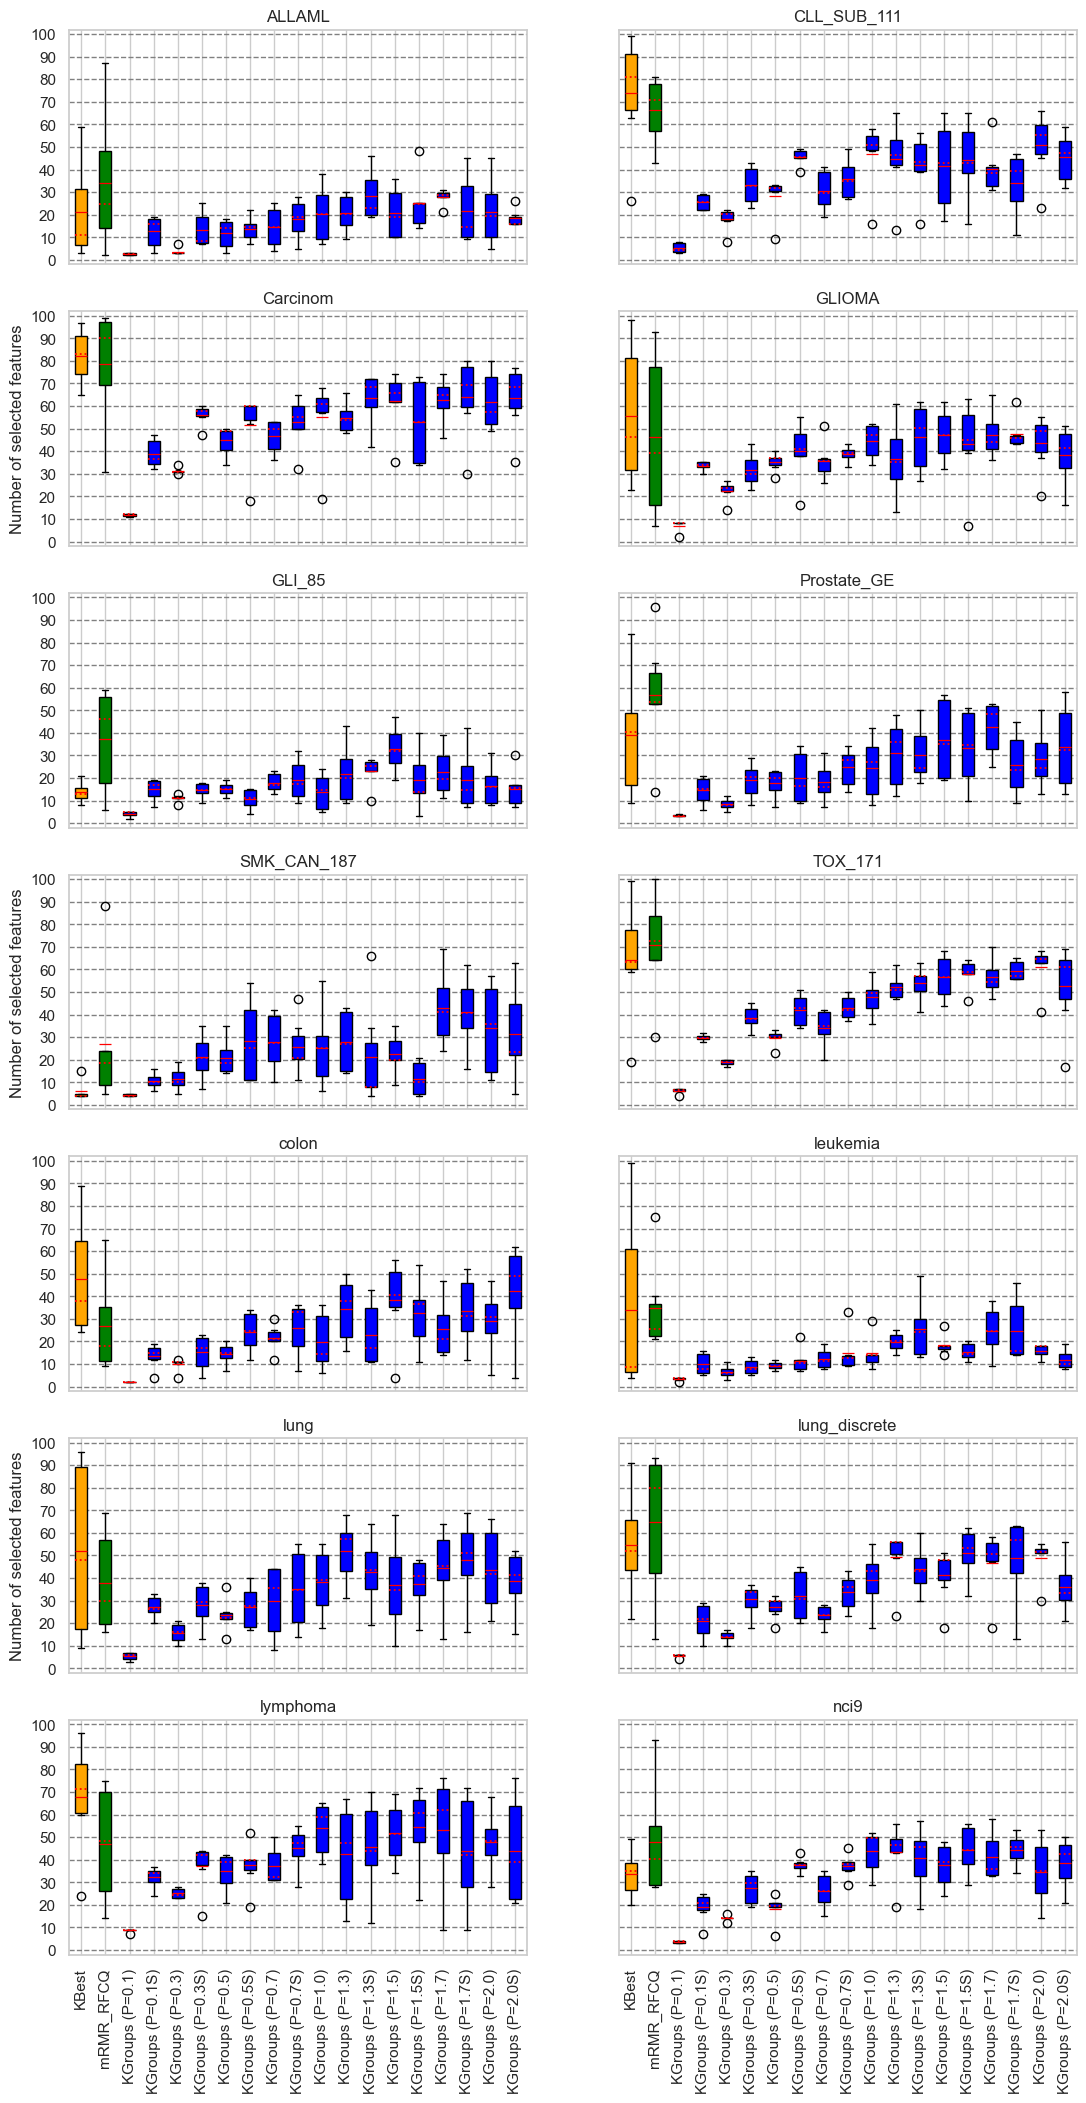

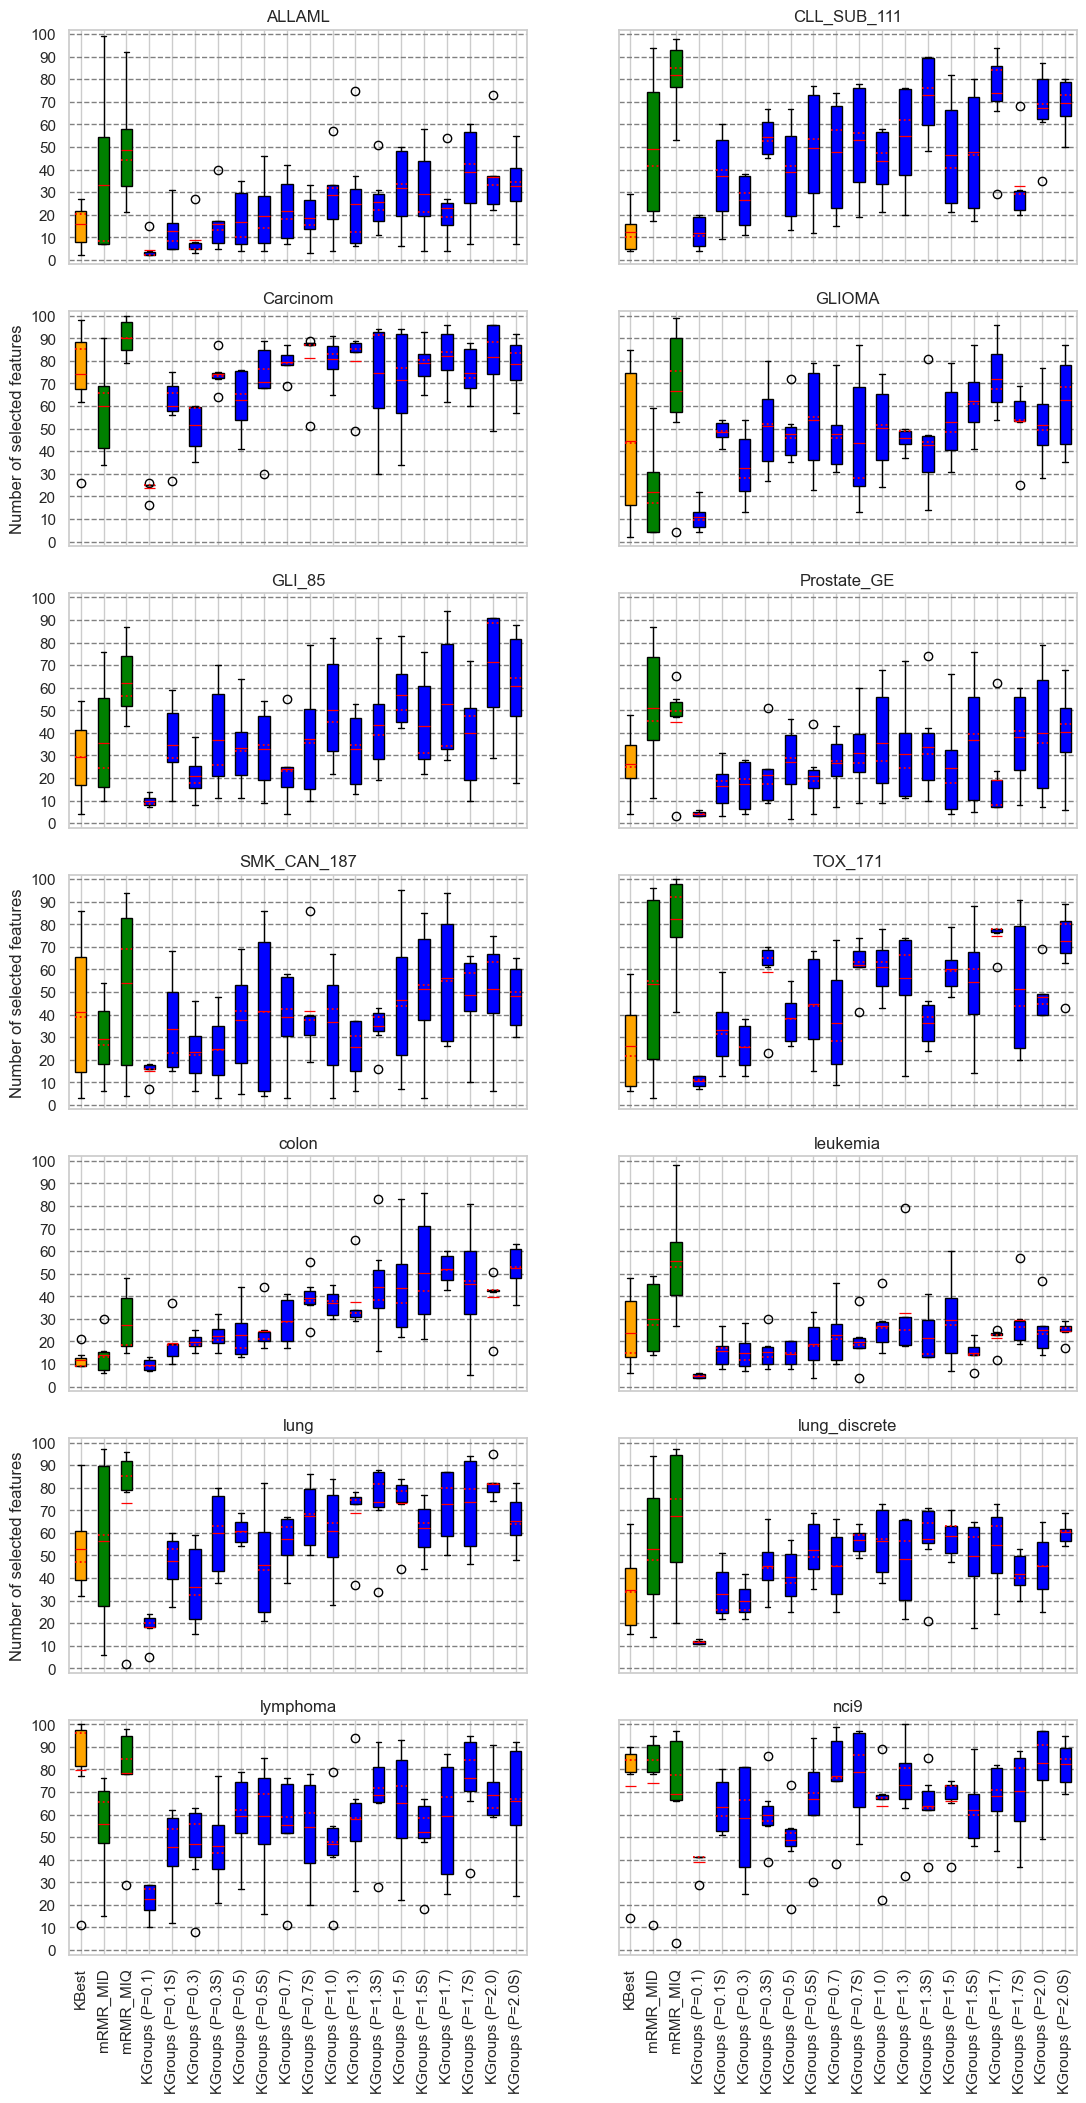

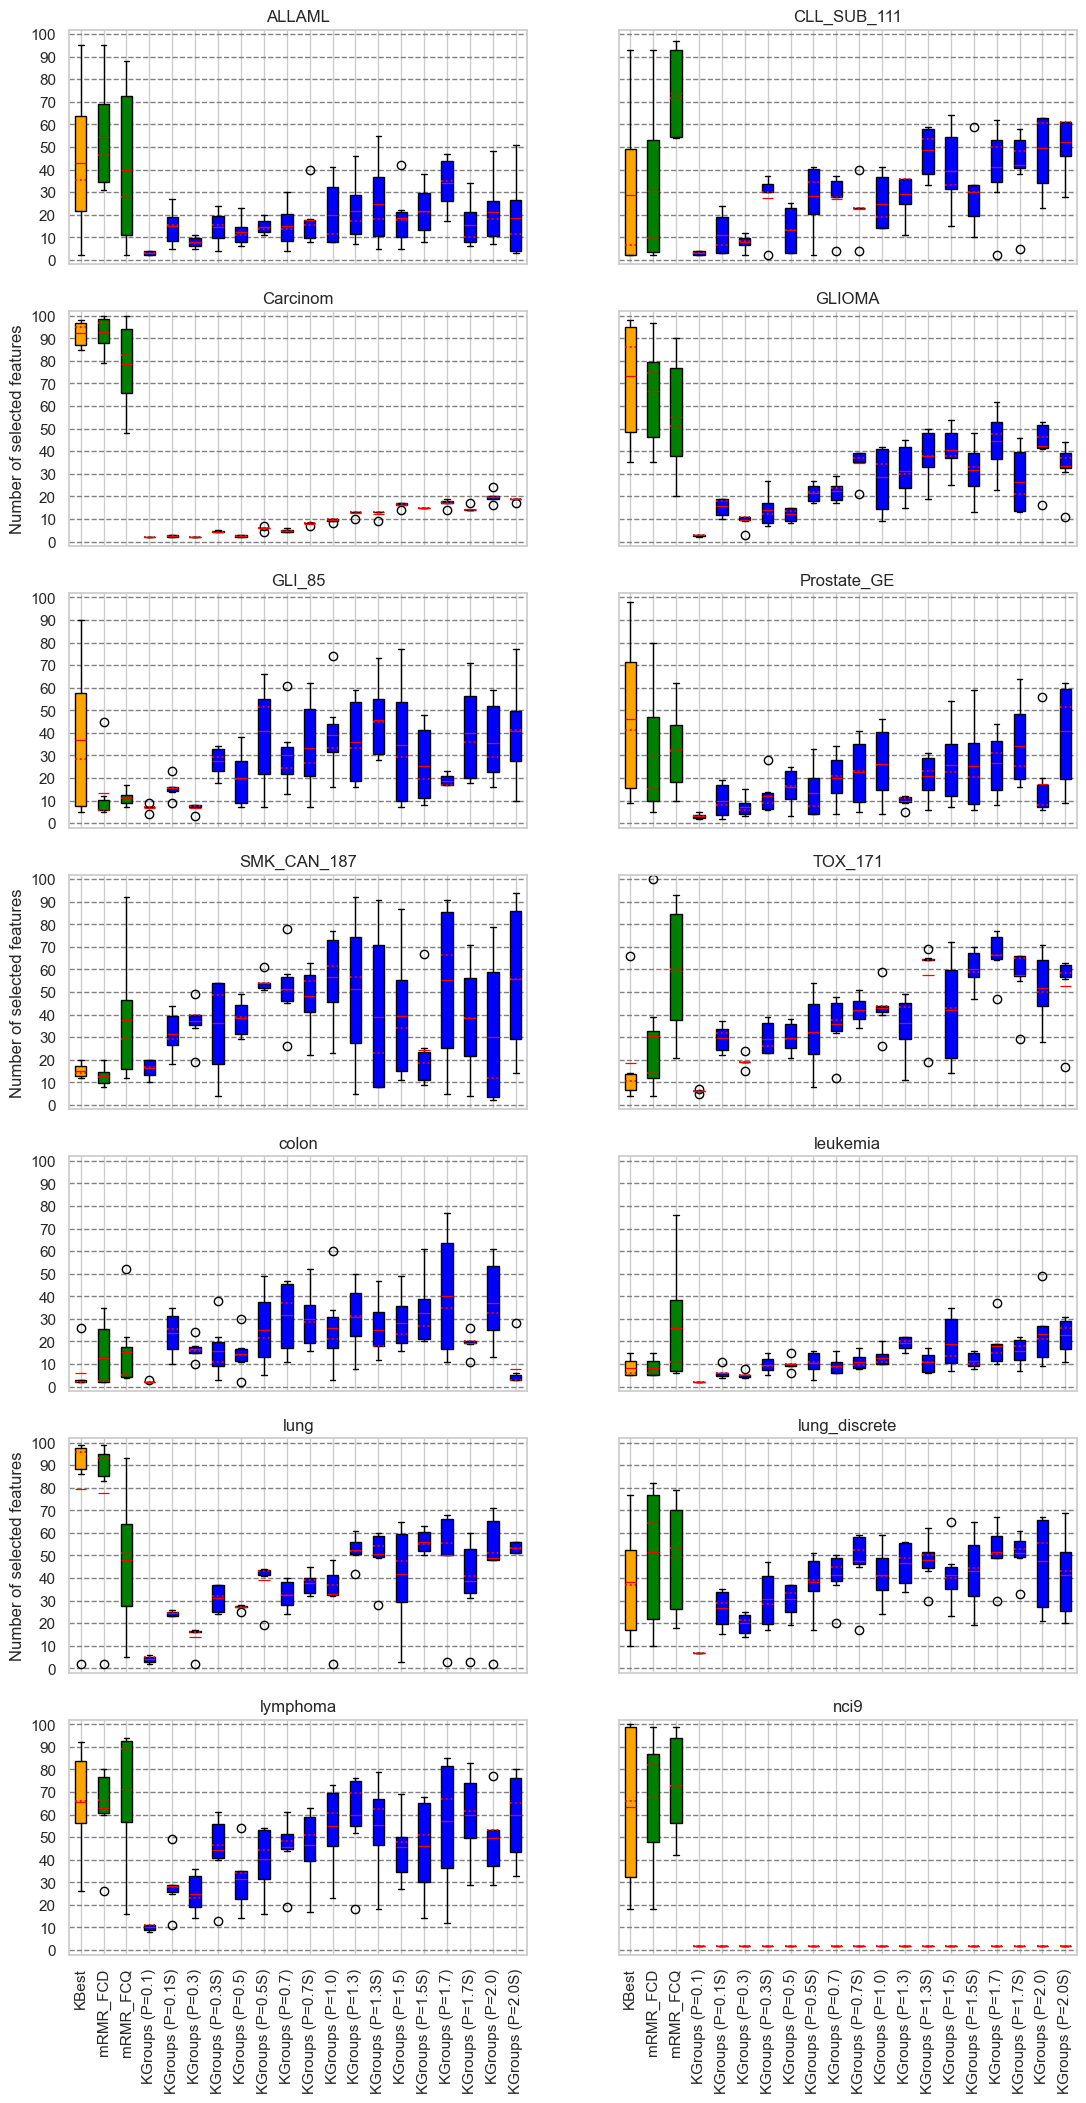

In [36]:
imgs_saving_dir = "./outputs/extracted_results/imgs"
check_or_create_directory(imgs_saving_dir)

fig2, ax2 = plt.subplots(nrows=7, ncols =2, figsize=(21 if include_KGpplus else 13, 25))
fig3, ax3 = plt.subplots(nrows=7, ncols =2, figsize=(21 if include_KGpplus else 13,25))
fig4, ax4 = plt.subplots(nrows=7, ncols =2, figsize=(21 if include_KGpplus else 13,25))
# fig5, ax5 = plt.subplots(nrows=5, ncols =3, figsize=(21 if include_KGpplus else 13,25))

# ymin, ymax = -5, 0
ax2 = ax2.flatten()
ax3 = ax3.flatten()
ax4 = ax4.flatten()
# ax5 = ax5.flatten()

# Define properties
# medianprops = dict(linestyle='dotted', linewidth=1., color='yellow')
# meanprops = dict(linestyle='-', linewidth=1., color='khaki')
medianprops = dict(linestyle='dotted', linewidth=1.3, color='red')
meanprops = dict(linestyle='-', linewidth=.9, color='red')

ymin, ymax = 0, 102

col_to_use = None

for valuation_method in valuation_method_list:
# for valuation_method in [list(valuation_method_list)[1]]:

    df_max, df_mean, df_std = None, None, None 
    print("\nValuation method: {}".format(valuation_method))
    df_out = pd.DataFrame()
    ## Solution => concat + groupby dataset
    dfs_list = []
    for filename in glob(pathjoin(saving_dir, "{}-*-formatted.csv".format(valuation_method))):
        print(filename)
        df = pd.read_csv(filename)
        df = df.replace("-", np.nan)
        
        for col in list(set(df.columns)-set(['dataset_name'])):
            df[col] = df[col].apply(extract_num_features)
            df[col] = df[col].astype(np.float64)
            
        # col_KG = [col for col in df.columns if "KGroups_max" in col]
        # df_kg = df[["dataset_name"]+col_KG]
        # df_kg["KGroups_max (all)"] = df_kg[col_KG].max(axis=1)
        
        df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(["Carcinom", "SMK_CAN_187"])].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(["Carcinom"])].reset_index(drop=True)
        
        
        dfs_list += [df]
        
    df_max = pd.concat(dfs_list).groupby(["dataset_name"]).max().reset_index()
    df_max = df_max.replace(np.nan,"-")
    # df_max.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "max_selected"), index=False)

    df_min = pd.concat(dfs_list).groupby(["dataset_name"]).min().reset_index()
    df_min = df_min.replace(np.nan,"-")
    # df_min.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "min_selected"), index=False)
    
    df_mean = pd.concat(dfs_list).groupby(["dataset_name"]).mean().reset_index()
    df_std = pd.concat(dfs_list).groupby(["dataset_name"]).std().reset_index()
    df_agg = upgrade_aggregated_results_presentation(df_mean, df_std)
    df_agg = df_agg.replace("nan±nan","-")
    # df_agg.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "mean_selected"), index=False)
    
    # display(df_max, df_min, df_agg)

    # Uncomment below to show figures
    df_all = pd.concat(dfs_list).reset_index(drop=True)#.groupby(["dataset_name", ""]).mean().reset_index()

    # ## Renaming KGroups columns - Already done above
    # df_all.columns = [ col.replace("KGroups_max (P","KGroups (α") for col in df_all.columns ]
    # df_all.columns = [ col.replace("KGroups_max++ (P","KGroups++ (α") for col in df_all.columns ]
    
    for i, dataset_name in enumerate(df_all["dataset_name"].unique()):
        # print(i, dataset_name)
        if valuation_method == 'gini':
            if include_KGpplus:
                col_to_use = list(df_all.columns)
            else:
                col_to_use = [col for col in df_all.columns if not "KGroups++ (" in col ]
            
            # bplot = df_all[df_all["dataset_name"]==dataset_name][col_to_use].plot(kind="box", rot=90, ax=ax2[i], color=update_colormap(col_to_use[1:]).values())

            colors = update_colormap(col_to_use[1:])
            ax2_plot = ax2[i].boxplot(
                df_all[df_all["dataset_name"]==dataset_name][colors.keys()].values, 
                patch_artist=True, tick_labels=colors.keys(),
                meanline=True, showmeans=True,
                medianprops=medianprops, meanprops=meanprops,
            )  
            
            # df_all[df_all["dataset_name"]==dataset_name].plot(kind="box", rot=90, ax=ax2[i])
            ax2[i].set_title(dataset_name)
            ax2[i].set_ylim(ymin-2,ymax)
            ax2[i].set_yticks(np.arange(ymin,ymax,10))
            ax2[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
            if i in [2,6,10]:
                ax2[i].set_ylabel("Number of selected features")
            if i < 12:
                ax2[i].set_xticklabels([])
            else:
                ax2[i].set_xticklabels(colors.keys(), rotation=90, ha='center')
            if i in range(1,15,2):
                ax2[i].set_yticklabels([])

            # fill with colors
            for patch, color in zip(ax2_plot['boxes'], colors.values()):
                patch.set_facecolor(color)
                
        elif valuation_method == 'mutual_info':
            if include_KGpplus:
                col_to_use = list(df_all.columns)
            else:
                col_to_use = [col for col in df_all.columns if not "KGroups++ (" in col ]
            
            
            # df_all[df_all["dataset_name"]==dataset_name][col_to_use].plot(kind="box", rot=90, ax=ax3[i], color=update_colormap(col_to_use[1:]).values)
            
            colors = update_colormap(col_to_use[1:])
            ax3_plot = ax3[i].boxplot(
                df_all[df_all["dataset_name"]==dataset_name][colors.keys()].values, 
                patch_artist=True, tick_labels=colors.keys(),
                meanline=True, showmeans=True,
                medianprops=medianprops, meanprops=meanprops,
            )  
            
            # df_all[df_all["dataset_name"]==dataset_name].plot(kind="box", rot=90, ax=ax3[i])
            ax3[i].set_title(dataset_name)
            ax3[i].set_ylim(ymin-2,ymax)
            ax3[i].set_yticks(np.arange(ymin,ymax,10))
            ax3[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
            if i in [2,6,10]:
                ax3[i].set_ylabel("Number of selected features")
            if i < 12:
                ax3[i].set_xticklabels([])
            else:
                ax3[i].set_xticklabels(colors.keys(), rotation=90, ha='center')
            if i in range(1,15,2):
                ax3[i].set_yticklabels([])

            # fill with colors
            for patch, color in zip(ax3_plot['boxes'], colors.values()):
                patch.set_facecolor(color)
                
        elif valuation_method == 'Fvalue':
            if include_KGpplus:
                col_to_use = list(df_all.columns)
            else:
                col_to_use = [col for col in df_all.columns if not "KGroups++ (" in col ]
            
            # df_all[df_all["dataset_name"]==dataset_name][col_to_use].plot(kind="box", rot=90, ax=ax4[i], color=update_colormap(col_to_use[1:]).values)
            
            colors = update_colormap(col_to_use[1:])
            ax4_plot = ax4[i].boxplot(
                df_all[df_all["dataset_name"]==dataset_name][colors.keys()].values, 
                patch_artist=True, tick_labels=colors.keys(),
                meanline=True, showmeans=True,
                medianprops=medianprops, meanprops=meanprops,
            )  
            
            # df_all[df_all["dataset_name"]==dataset_name].plot(kind="box", rot=90, ax=ax4[i])
            ax4[i].set_title(dataset_name)
            ax4[i].set_ylim(ymin-2,ymax)
            ax4[i].set_yticks(np.arange(ymin,ymax,10))
            ax4[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
            if i in [2,6,10]:
                ax4[i].set_ylabel("Number of selected features")
            if i < 12:
                ax4[i].set_xticklabels([])
            else:
                ax4[i].set_xticklabels(colors.keys(), rotation=90, ha='center')
            if i in range(1,15,2):
                ax4[i].set_yticklabels([])

            # fill with colors
            for patch, color in zip(ax4_plot['boxes'], colors.values()):
                patch.set_facecolor(color)
                
                
        else:
            pass
    
    if valuation_method == 'gini':
        fig2.savefig(imgs_saving_dir+"/num_selected_for_{}.png".format(valuation_method), dpi=600, bbox_inches='tight')
    elif valuation_method == 'mutual_info':
        fig3.savefig(imgs_saving_dir+"/num_selected_for_{}.png".format(valuation_method), dpi=600, bbox_inches='tight')
    elif valuation_method == 'Fvalue':
        fig4.savefig(imgs_saving_dir+"/num_selected_for_{}.png".format(valuation_method), dpi=600, bbox_inches='tight')
    
fig2.show()
fig3.show()
fig4.show()
# fig5.show()

In [39]:
for valuation_method in valuation_method_list:
# for valuation_method in [list(valuation_method_list)[1]]:

    df_max, df_mean, df_std = None, None, None 
    print("\nValuation method: {}".format(valuation_method))
    df_out = pd.DataFrame()
    ## Solution => concat + groupby dataset
    dfs_list = []
    for filename in glob(pathjoin(saving_dir, "{}-*-formatted.csv".format(valuation_method))):
        print(filename)
        df = pd.read_csv(filename)
        col_KG = [col for col in df.columns if "KGroups_max" in col]
        df_kg = df[["dataset_name"]+col_KG]
        df_kg["KGroups_max (all)"] = df_kg[col_KG].max(axis=1)
        df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(["Carcinom", "SMK_CAN_187"])].reset_index(drop=True)
        df = df[~df["dataset_name"].isin(["Carcinom"])].reset_index(drop=True)
        
        df = df.replace("-", np.nan)
        
        for col in list(set(df.columns)-set(['dataset_name'])):
            df[col] = df[col].apply(extract_num_features)
            df[col] = df[col].astype(np.float64)
        dfs_list += [df]
        
    df_max = pd.concat(dfs_list).groupby(["dataset_name"]).max().reset_index()
    df_max = df_max.replace(np.nan,"-")
    # df_max.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "max_selected"), index=False)

    df_min = pd.concat(dfs_list).groupby(["dataset_name"]).min().reset_index()
    df_min = df_min.replace(np.nan,"-")
    # df_min.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "min_selected"), index=False)
    
    df_mean = pd.concat(dfs_list).groupby(["dataset_name"]).mean().reset_index()
    df_std = pd.concat(dfs_list).groupby(["dataset_name"]).std().reset_index()
    df_agg = upgrade_aggregated_results_presentation(df_mean, df_std)
    df_agg = df_agg.replace("nan±nan","-")
    # df_agg.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "mean_selected"), index=False)
    
    # display(df_max, df_min, df_agg)

    # Uncomment below to show figures
    df_all = pd.concat(dfs_list).reset_index(drop=True)#.groupby(["dataset_name", ""]).mean().reset_index()
    df_all.columns = [ col.replace("KGroups_max (P","KGroups (α") for col in df_all.columns ]

    display(
        # df_all.describe(),
        df_agg,
    )


Valuation method: mutual_info
./outputs/extracted_results/mutual_info-LinearSVC-formatted.csv
./outputs/extracted_results/mutual_info-KNeighbors-formatted.csv
./outputs/extracted_results/mutual_info-MLP-formatted.csv
./outputs/extracted_results/mutual_info-GaussianNB-formatted.csv
./outputs/extracted_results/mutual_info-XGB-formatted.csv
./outputs/extracted_results/mutual_info-RandomForest-formatted.csv


,dataset_name,KBest,mRMR_MID,mRMR_MIQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S)
0,ALLAML,16.0±10.37,33.17±40.52,48.67±25.58,4.5±5.21,12.67±10.41,8.83±9.04,15.83±12.88,16.83±14.37,19.33±16.71,21.83±14.99,18.33±11.24,28.67±18.27,24.83±27.14,25.5±14.2,31.83±18.47,29.0±20.88,22.83±17.03,38.83±21.92,36.83±18.87,32.83±16.31,11.33±3.78,29.17±14.8,29.17±10.38,25.0±10.24,23.0±16.05,24.5±17.41,29.33±11.15,26.67±26.79,37.83±19.16,35.5±19.86,26.67±17.15,40.33±27.37,37.67±20.97,41.0±22.87,41.0±28.15,34.67±30.33,41.5±31.27
1,CLL_SUB_111,12.33±9.75,49.0±32.84,81.67±16.37,11.83±7.39,37.0±20.88,26.33±12.61,54.33±9.24,39.0±22.39,49.5±28.18,47.83±27.04,53.17±25.52,43.83±15.54,55.0±24.43,73.0±18.37,46.5±26.37,47.67±28.18,73.83±23.81,32.83±17.88,67.33±18.61,69.5±11.88,15.5±6.41,50.17±23.34,34.0±19.64,37.17±25.93,39.83±23.4,36.17±26.73,46.33±29.86,50.67±27.62,50.0±31.5,45.5±27.46,46.17±36.14,35.67±22.86,38.5±23.3,47.0±19.69,43.5±31.85,53.0±22.78,50.0±33.73
2,GLIOMA,44.33±35.12,22.0±22.3,66.67±34.84,10.83±6.52,48.67±4.93,32.5±16.49,51.33±20.24,47.83±13.53,53.83±23.89,47.5±17.42,43.5±31.93,50.33±19.91,45.83±5.46,42.83±22.66,52.83±18.9,62.33±16.48,72.17±16.19,53.33±15.4,51.5±17.17,62.5±22.26,15.0±5.73,28.5±18.84,29.17±18.59,31.5±18.83,26.67±13.57,44.5±33.74,53.83±28.63,43.33±22.48,39.33±24.23,64.33±23.11,49.17±34.95,66.67±15.34,53.17±19.05,58.83±28.49,53.17±9.43,65.17±18.83,56.33±30.31
3,GLI_85,29.17±18.78,35.67±27.82,62.17±17.14,9.67±2.73,34.83±18.68,20.83±10.59,36.67±25.11,33.33±18.74,33.0±18.22,24.0±17.12,37.33±26.96,50.17±24.96,32.83±17.33,43.5±22.88,56.67±16.56,43.0±23.58,52.83±31.97,39.83±24.84,71.33±28.81,60.67±27.27,12.67±2.07,22.5±12.97,20.17±12.38,46.0±23.38,31.5±15.49,42.33±23.07,44.67±16.69,42.17±12.29,45.17±20.86,46.5±20.74,49.17±25.18,72.5±14.01,74.83±20.23,51.33±18.92,59.0±26.25,53.17±21.7,60.17±25.47
4,Prostate_GE,26.33±15.2,51.0±29.22,44.83±21.49,4.17±1.33,16.67±10.44,17.17±11.43,21.5±16.01,27.0±16.53,20.83±13.32,26.83±12.84,31.17±17.9,35.33±24.98,30.83±23.95,33.83±22.81,24.33±23.91,37.0±29.48,19.17±21.89,38.17±21.28,39.83±29.95,40.5±21.41,3.67±2.34,12.5±7.94,10.83±6.77,13.0±11.3,11.83±8.89,28.33±18.67,18.0±11.4,26.33±7.92,17.33±11.34,35.83±28.78,33.33±28.91,43.83±25.62,32.5±27.38,24.5±20.15,31.33±18.77,51.5±29.28,20.5±22.12
5,SMK_CAN_187,41.33±33.28,29.17±18.2,54.0±40.37,15.17±4.12,33.83±23.43,23.5±14.47,24.67±16.82,37.5±24.84,41.5±38.91,39.0±21.65,41.5±23.14,36.83±25.21,25.5±13.87,34.83±10.11,46.33±33.24,51.17±30.24,56.33±30.73,48.83±21.7,51.5±26.55,48.17±15.24,17.5±2.74,20.0±17.92,23.83±19.6,20.0±23.99,19.33±16.8,21.33±32.46,31.5±34.15,19.0±29.79,12.17±14.37,15.17±14.55,20.17±31.13,19.17±7.19,25.33±20.37,33.17±32.88,34.67±36.71,14.33±9.18,13.0±7.62
6,TOX_171,26.17±21.71,53.5±42.22,82.17±23.11,10.5±2.81,33.0±16.75,25.83±10.76,59.0±17.97,38.33±11.54,44.5±22.31,36.33±25.92,62.0±11.42,61.17±12.92,56.33±24.03,36.5±9.81,60.33±11.18,54.33±26.25,74.83±6.82,51.5±31.7,47.83±11.27,72.83±16.94,9.67±2.5,34.17±17.77,21.17±5.04,48.5±26.1,31.5±16.53,53.33±21.23,48.67±25.12,55.5±22.56,55.83±23.05,64.17±26.1,47.83±24.75,70.83±27.18,53.33±26.45,56.5±26.56,61.67±25.45,47.5±40.21,50.67±17.66
7,colon,11.83±4.92,14.0±8.85,27.33±15.31,9.67±2.73,19.17±9.54,19.67±3.67,22.33±6.12,22.67±12.37,24.67±9.83,29.0±11.08,39.17±10.17,37.17±6.18,37.33±13.69,44.33±22.84,43.67±23.37,50.17±26.81,52.0±7.01,45.33±26.63,39.67±12.06,52.5±10.25,6.83±0.75,11.83±11.32,22.0±10.28,29.67±7.31,18.67±20.45,33.17±23.96,20.17±7.91,27.67±7.26,4


Valuation method: gini
./outputs/extracted_results/gini-MLP-formatted.csv
./outputs/extracted_results/gini-RandomForest-formatted.csv
./outputs/extracted_results/gini-XGB-formatted.csv
./outputs/extracted_results/gini-KNeighbors-formatted.csv
./outputs/extracted_results/gini-LinearSVC-formatted.csv
./outputs/extracted_results/gini-GaussianNB-formatted.csv


,dataset_name,KBest,mRMR_RFCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S)
0,ALLAML,21.17±22.21,34.17±31.51,2.5±0.55,12.67±7.31,3.67±1.63,13.0±8.22,11.67±6.65,13.83±5.42,14.5±9.01,18.0±8.79,20.5±12.88,20.67±8.55,28.17±11.48,20.67±11.98,25.0±12.43,27.83±3.54,21.67±15.74,21.33±15.13,18.33±4.08,3.0±0.0,6.0±4.29,3.67±0.82,4.83±3.13,6.17±4.58,3.83±1.17,4.0±1.26,5.0±3.16,7.67±5.35,7.33±2.66,7.67±2.66,14.83±14.11,14.0±16.86,7.67±1.03,14.5±13.79,17.67±14.04,12.83±12.37
1,CLL_SUB_111,73.83±26.61,66.5±15.29,5.17±2.32,25.5±3.51,18.17±5.27,33.0±8.65,28.17±9.45,45.5±3.67,30.67±9.05,35.83±8.95,46.67±15.47,44.5±17.59,41.83±14.36,41.5±20.3,44.17±17.7,40.33±11.06,34.17±14.47,50.83±15.43,45.33±11.2,4.17±0.75,24.0±7.32,13.17±5.27,29.33±12.16,28.0±7.16,27.0±11.42,31.67±11.72,33.33±15.12,39.0±11.97,45.5±19.73,45.17±16.04,51.5±18.12,45.33±12.74,56.67±8.94,59.83±6.18,49.83±8.18,61.67±6.12
2,GLIOMA,55.67±31.81,46.17±37.19,7.0±2.45,33.5±1.97,22.5±4.51,31.67±7.45,35.33±4.23,40.0±13.46,35.83±8.52,38.67±3.44,44.67±7.87,36.33±16.78,46.5±15.37,47.17±12.02,43.17±20.04,47.33±10.63,47.83±7.14,43.67±13.13,38.17±13.17,4.5±1.97,20.33±10.17,20.5±5.09,33.5±16.44,26.17±11.67,37.83±17.79,31.17±15.89,35.83±22.37,40.83±12.59,53.17±13.44,39.67±22.16,43.0±28.88,40.5±21.85,40.17±30.0,36.67±17.42,27.17±19.22,37.67±30.59
3,GLI_85,13.67±4.5,37.5±23.98,4.17±1.33,15.0±4.94,11.0±1.67,14.5±3.39,15.0±2.9,10.67±4.41,18.0±4.34,19.17±9.45,14.0±8.2,21.83±13.29,23.17±6.74,32.83±10.38,19.0±13.45,22.5±11.17,19.0±13.84,16.67±9.03,15.33±8.45,3.83±1.17,13.0±4.43,7.83±2.93,14.17±9.62,13.33±2.42,15.17±9.81,15.67±8.21,17.83±13.41,15.67±11.96,18.17±7.25,19.0±10.35,18.0±14.9,19.17±7.19,16.83±7.78,16.5±7.89,21.0±7.82,29.83±6.82
4,Prostate_GE,39.17±27.91,56.83±26.86,3.33±0.52,14.5±6.12,8.33±2.5,19.0±7.9,17.67±6.41,19.83±11.69,18.17±8.61,24.83±8.68,24.67±13.88,31.17±15.46,30.33±12.94,37.0±18.68,33.33±17.77,42.67±12.72,26.0±14.39,28.5±13.46,33.83±19.01,3.5±0.55,6.0±2.0,6.67±1.86,13.67±8.71,13.83±6.77,18.17±10.5,14.5±9.61,24.17±15.28,20.33±12.11,21.0±14.68,20.33±11.79,23.67±15.79,30.83±19.95,30.33±19.0,26.17±16.51,25.5±14.6,31.83±17.36
5,SMK_CAN_187,6.0±4.43,26.83±30.98,4.33±0.52,10.67±3.5,11.5±5.13,21.17±10.26,21.0±8.17,28.17±19.44,27.83±12.97,25.67±12.77,25.33±17.63,28.0±14.18,21.33±24.45,22.5±9.27,11.67±7.81,43.0±16.7,41.0±16.4,34.0±21.03,31.33±21.44,4.67±0.52,19.0±12.65,10.17±3.76,16.17±16.68,14.33±8.76,16.33±13.17,19.83±14.61,25.0±20.51,29.17±19.56,13.83±5.81,25.0±21.09,24.5±23.53,26.33±21.46,24.17±9.54,13.83±5.08,25.67±19.88,32.0±21.57
6,TOX_171,64.33±26.83,70.67±24.01,6.17±1.17,29.83±1.47,18.83±1.17,38.67±5.2,29.67±3.5,42.17±7.28,34.17±8.4,43.0±5.4,47.67±8.09,52.17±5.67,53.83±7.91,56.5±9.93,58.17±6.46,56.5±8.07,59.33±4.46,61.17±10.07,52.5±19.72,6.5±0.55,28.67±2.94,19.17±0.98,38.17±3.6,30.0±2.37,37.0±9.36,36.5±5.86,50.67±7.42,51.17±6.91,52.5±12.53,52.67±8.71,56.83±7.03,59.17±10.11,59.67±8.64,64.67±2.8,55.5±21.64,54.0±13.8
7,colon,47.67±26.76,26.67±21.91,2.0±0.0,13.67±5.43,10.0±2.97,15.17±8.04,14.5±4.64,24.33±9.18,21.5±5.96,26.17±12.72,19.67±13.13,34.33±14.45,23.0±14.6,38.17±18.81,32.5±15.55,25.33±13.11,33.33±15.49,29.0±14.55,42.5±21.88,2.0±0.0,13.0±4.56,10.17±3.37,14.5±8.67,11.83±0.98,9.0±1.9,12.33±7.53,12.33±11.71,16.17±14.03,18.5±10.01,14.33±9.16,13.5±11.52,23.0±21.2,16.0±17.82,25.83±19.83,16.17±20.17,32.17±24.33
8,leukemia,34.0±42.77,34.83±20.86,3.5±0.84,9.83±5.08,6.5±2.81,8.67±3.27,9.33±1.86,11.5±5.54,12.33±4.5,15.0±9.06,14.83±7.39,19.83±4.4,25.5±13.


Valuation method: Fvalue
./outputs/extracted_results/Fvalue-KNeighbors-formatted.csv
./outputs/extracted_results/Fvalue-MLP-formatted.csv
./outputs/extracted_results/Fvalue-GaussianNB-formatted.csv
./outputs/extracted_results/Fvalue-RandomForest-formatted.csv
./outputs/extracted_results/Fvalue-LinearSVC-formatted.csv
./outputs/extracted_results/Fvalue-XGB-formatted.csv


,dataset_name,KBest,mRMR_FCD,mRMR_FCQ,KGroups (P=0.1),KGroups (P=0.1S),KGroups (P=0.3),KGroups (P=0.3S),KGroups (P=0.5),KGroups (P=0.5S),KGroups (P=0.7),KGroups (P=0.7S),KGroups (P=1.0),KGroups (P=1.3),KGroups (P=1.3S),KGroups (P=1.5),KGroups (P=1.5S),KGroups (P=1.7),KGroups (P=1.7S),KGroups (P=2.0),KGroups (P=2.0S),KGroups++ (P=0.1),KGroups++ (P=0.1S),KGroups++ (P=0.3),KGroups++ (P=0.3S),KGroups++ (P=0.5),KGroups++ (P=0.5S),KGroups++ (P=0.7),KGroups++ (P=0.7S),KGroups++ (P=1.0),KGroups++ (P=1.3),KGroups++ (P=1.3S),KGroups++ (P=1.5),KGroups++ (P=1.5S),KGroups++ (P=1.7),KGroups++ (P=1.7S),KGroups++ (P=2.0),KGroups++ (P=2.0S)
0,ALLAML,43.0±34.85,54.33±25.7,39.83±38.49,3.0±0.89,14.83±8.38,7.83±2.32,14.5±7.48,12.33±6.35,14.67±3.56,15.0±9.67,17.5±11.79,19.67±15.63,21.5±14.84,24.5±19.8,18.67±13.14,21.83±11.69,34.0±11.93,15.33±11.22,21.33±15.12,18.33±19.01,2.5±0.55,6.83±4.49,6.33±3.83,3.67±1.86,8.33±6.22,2.5±0.84,6.17±4.96,3.0±2.0,11.0±19.26,13.67±24.43,4.17±3.49,3.83±0.41,2.83±0.98,15.83±24.24,6.67±3.01,26.83±35.8,8.17±13.66
1,CLL_SUB_111,28.67±39.23,30.5±39.39,73.83±21.27,3.0±1.1,10.83±9.83,7.83±3.49,27.33±12.77,13.33±11.34,28.33±15.77,27.0±12.1,22.67±11.4,24.67±13.23,29.33±10.8,48.5±12.26,39.5±19.09,29.83±16.95,41.17±21.94,42.0±19.4,49.33±19.36,52.17±14.29,2.17±0.41,12.67±6.09,6.67±1.37,12.17±9.43,15.0±8.25,14.5±8.53,18.0±12.93,13.67±11.41,14.17±9.3,30.17±20.06,18.0±12.65,18.5±22.26,28.83±23.59,25.83±24.78,16.67±16.44,31.0±24.48,27.0±24.87
2,GLIOMA,73.17±29.1,66.5±24.78,55.17±27.66,2.67±0.52,15.67±4.46,9.33±3.2,14.0±7.75,12.17±3.43,21.67±4.13,22.5±4.72,34.67±6.98,28.5±15.63,31.17±12.14,38.0±12.03,40.5±10.58,31.67±12.64,44.67±14.21,26.33±15.38,42.5±13.98,33.33±11.74,2.0±0.0,8.83±6.55,4.5±2.07,10.67±8.69,8.17±6.88,10.5±10.29,9.83±8.86,6.67±5.32,14.33±16.51,7.5±9.25,13.33±17.49,13.17±12.54,8.17±10.85,10.17±12.7,14.5±15.0,15.83±22.6,9.5±9.46
3,GLI_85,36.67±34.95,13.33±15.72,11.17±3.6,6.83±1.6,15.5±4.51,6.83±1.94,27.67±6.71,20.0±12.76,40.67±24.52,30.17±16.87,33.33±21.82,39.17±19.71,36.0±19.62,45.83±17.76,34.67±28.93,25.33±18.26,18.83±2.86,39.83±23.03,35.67±18.82,40.83±23.25,8.33±1.21,18.5±8.62,16.0±8.15,24.83±13.63,21.0±6.26,42.17±12.5,24.5±11.59,18.17±9.43,29.33±18.73,18.0±10.58,21.17±13.3,24.0±15.92,19.0±10.49,34.67±29.4,32.5±20.41,41.5±27.99,30.5±24.95
4,Prostate_GE,46.33±36.47,30.17±30.86,32.83±19.48,3.17±1.17,9.83±7.63,7.17±4.54,12.0±8.46,15.83±8.66,13.17±12.22,20.17±11.23,22.67±15.51,26.33±16.86,10.0±2.68,21.0±10.14,25.67±18.04,25.17±20.8,26.83±15.01,34.17±20.29,17.5±19.55,40.83±24.62,3.67±1.21,10.33±8.07,4.0±1.1,19.67±11.13,17.83±8.38,25.0±11.31,22.17±9.2,26.33±7.09,25.0±16.89,31.0±14.01,25.83±16.46,37.0±17.44,25.0±16.0,28.33±20.03,26.83±17.8,45.33±24.16,22.17±16.59
5,SMK_CAN_187,15.17±3.19,12.83±4.36,37.67±30.58,16.17±4.4,31.5±10.13,37.0±10.04,36.5±23.32,38.5±8.17,54.17±3.66,51.5±17.0,48.33±15.67,56.67±21.1,51.33±34.02,39.17±38.57,39.5±29.86,24.5±21.72,55.33±37.33,38.33±25.41,30.0±36.05,56.0±35.65,15.33±3.67,22.0±23.38,18.17±15.11,26.0±26.17,30.5±21.21,24.17±20.41,31.17±20.53,37.5±34.49,37.67±20.5,39.67±17.08,41.5±20.77,36.33±24.4,40.83±23.93,28.17±13.29,30.0±16.82,40.0±26.78,37.33±13.11
6,TOX_171,18.5±23.56,30.33±36.14,59.5±30.64,6.0±0.63,29.83±6.34,19.17±2.86,29.33±7.84,29.83±7.11,32.33±17.13,35.67±13.22,42.17±6.31,42.83±10.55,36.17±14.92,57.5±18.96,41.83±24.09,60.17±8.8,66.33±11.02,57.67±14.68,51.67±16.12,52.67±17.69,5.33±0.82,22.17±11.55,18.17±6.27,26.0±13.33,26.17±11.62,38.0±4.69,36.17±6.97,25.17±12.78,39.83±17.05,50.33±13.97,54.67±11.71,46.0±23.98,55.33±8.02,59.17±18.05,62.83±15.9,56.83±15.46,63.67±14.0
7,colon,6.17±9.72,12.83±16.41,15.33±19.28,2.17±0.41,23.83±10.03,16.5±4.59,15.67±12.61,14.67±9.14,25.0±17.4,31.83±16.57,30.0±13.64,25.83±19.49,30.83±15.46,25.17±13.92,28.33±12.96,32.83±16.08,40.33±28.63,19.33±4.8,37.0±19.44,7.67±10.03,3.5±0.84,12.17±6.27,14.17±5.15,12.67±6.5,18.33±8.52,21.67±7.31,14.0±12.25,12.5±8.67,14.33±11.98,17.0±12.7,16.67±7.84,30.83±22.52,14.83±8.01,33.67±24.73,20.33±18.22,18.33±15.85,24.67±15.02
8,le

## C-2) Performance scores

In [40]:
saving_dir = "./outputs/extracted_results"
output_dfs_list = glob(pathjoin(saving_dir, "*.csv"))
# output_dfs_list

valuation_method_list = set([filename.split("/")[-1].split("-")[0]  for filename in output_dfs_list])
model_list = set([filename.split("/")[-1].split("-")[1]  for filename in output_dfs_list])
# model_list = set([filename.split("/")[-1].split("-")[2].split(".")[0]  for filename in output_dfs_list])

valuation_method_list, model_list

({'Fvalue', 'gini', 'mutual_info'},
 {'GaussianNB', 'KNeighbors', 'LinearSVC', 'MLP', 'RandomForest', 'XGB'})

In [41]:
# output_dfs_list

extract_num_features ("98.67±2.98 (21)") , extract_performance_scores ("98.67±2.98 (21)")

('21', '98.67')

In [42]:
# sns.boxplot?

In [43]:
colormap ={
    "KGroups": "blue",
    "KBest": "red",
    "mRMR_RFCQ": "green",
    "mRMR_MIQ": "green",
    "mRMR_MID": "orange",
    "mRMR_FCQ": "green",
    "mRMR_FCD": "orange",
    "mRMR": "green",
}
# KGroups_max	mRMR_RFCQ mRMR_MIQ mRMR_MID mRMR_FCD mRMR_FCQ	KBest


In [45]:
# imgs_saving_dir = "./outputs/extracted_results/imgs"
# check_or_create_directory(imgs_saving_dir)

# # fig2, ax2 = plt.subplots(nrows=4, ncols =3, figsize=(12,12))
# # fig3, ax3 = plt.subplots(nrows=4, ncols =3, figsize=(12,12))
# # fig4, ax4 = plt.subplots(nrows=4, ncols =3, figsize=(12,12))

# # fig2, ax2 = plt.subplots(nrows=3, ncols =4, figsize=(10,8))
# # fig3, ax3 = plt.subplots(nrows=3, ncols =4, figsize=(10,8))
# # fig4, ax4 = plt.subplots(nrows=3, ncols =4, figsize=(10,8))

# # fig2, ax2 = plt.subplots(nrows=3, ncols =5, figsize=(15,10))
# # fig3, ax3 = plt.subplots(nrows=3, ncols =5, figsize=(15,10))
# # fig4, ax4 = plt.subplots(nrows=3, ncols =5, figsize=(15,10))

# fig21, ax21 = plt.subplots(nrows=3, ncols =5, figsize=(20,10))
# fig31, ax31 = plt.subplots(nrows=3, ncols =5, figsize=(20,10))
# fig41, ax41 = plt.subplots(nrows=3, ncols =5, figsize=(20,10))

# # ymin, ymax = -5, 0
# ax21 = ax21.flatten()
# ax31 = ax31.flatten()
# ax41 = ax41.flatten()

# ymin, ymax = 0, 102

# for valuation_method in valuation_method_list:
# # for valuation_method in [list(valuation_method_list)[1]]:

#     df_max, df_mean, df_std = None, None, None 
#     print("\nValuation method: {}".format(valuation_method))
#     df_out = pd.DataFrame()
#     ## Solution => concat + groupby dataset
#     dfs_list = []
#     for filename in glob(pathjoin(saving_dir, "{}-*-formatted.csv".format(valuation_method))):
#         print(filename)
#         df = pd.read_csv(filename)
#         df = df.replace("-", np.nan)
        
#         for col in list(set(df.columns)-set(['dataset_name'])):
#             df[col] = df[col].apply(extract_performance_scores)
#             df[col] = df[col].astype(np.float64)
        
#         # col_KG = [col for col in df.columns if "KGroups_max" in col]
#         # df_kg = df[["dataset_name"]+col_KG]
#         # df_kg["KGroups_max (all)"] = df_kg[col_KG].max(axis=1)
        
#         df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
#         # df = df[~df["dataset_name"].isin(["Carcinom", "SMK_CAN_187"])].reset_index(drop=True)
#         # df = df[~df["dataset_name"].isin(["Carcinom"])].reset_index(drop=True)
        
#         dfs_list += [df]
        
        
#     df_max = pd.concat(dfs_list).groupby(["dataset_name"]).max().reset_index()
#     df_max = df_max.replace(np.nan,"-")
#     # df_max.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "max_selected"), index=False)

#     df_min = pd.concat(dfs_list).groupby(["dataset_name"]).min().reset_index()
#     df_min = df_min.replace(np.nan,"-")
#     # df_min.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "min_selected"), index=False)
    
#     df_mean = pd.concat(dfs_list).groupby(["dataset_name"]).mean().reset_index()
#     df_std = pd.concat(dfs_list).groupby(["dataset_name"]).std().reset_index()
#     df_agg = upgrade_aggregated_results_presentation(df_mean, df_std)
#     df_agg = df_agg.replace("nan±nan","-")
#     # df_agg.to_csv("{}/{}-{}.csv".format(num_selected_features_dir, valuation_method, "mean_selected"), index=False)
    
#     # display(df_max, df_min, df_agg)

#     # Uncomment below to show figures
#     df_all = pd.concat(dfs_list).reset_index(drop=True)#.groupby(["dataset_name", ""]).mean().reset_index()
#     # df_all.columns = [ col.replace("KGroups_max (P","KGroups (P") for col in df_all.columns ]
#     # df_all.columns = [ col.replace("KGroups_max++ (P","KGroups++ (P") for col in df_all.columns ]
    
#     _df_all = df_all.melt(id_vars=["dataset_name"], value_vars=list(df_all.select_dtypes(exclude="object").columns)).rename(
#         columns={"variable":"selection_method" ,"value":"test_accuracy"}
#     )
            
#     for i, dataset_name in enumerate(df_all["dataset_name"].unique()):
#         # print(i, dataset_name)
#         if valuation_method == 'gini':
#             # df_all[df_all["dataset_name"]==dataset_name].set_index("dataset_name").plot(kind="bar", rot=90, ax=ax21[i])
#             # df_all[df_all["dataset_name"]==dataset_name].drop("dataset_name", axis=1).plot(kind="bar", rot=90, ax=ax21[i])
#             # df_all[df_all["dataset_name"]==dataset_name].plot(kind="bar", rot=90, ax=ax21[i])
#             sns.barplot(
#                 x="dataset_name", y="test_accuracy", hue="selection_method", estimator=np.mean, errorbar='sd', 
#                 data=_df_all[_df_all["dataset_name"]==dataset_name], ax=ax21[i]
#             )
#             ax21[i].get_legend().remove()
#             ax21[i].set_title(dataset_name)
#             ax21[i].set_ylim(ymin,ymax)
#             ax21[i].set_yticks(np.arange(ymin,ymax,10))
#             ax21[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
#             # if i in [0,6]:
#             if i in [5]:
#                 ax21[i].set_ylabel("Number of selected features")
#             if i < len(ax2)-6:
#                 ax21[i].set_xticklabels([])
#             if i not in [0,5,10]:
#                 ax21[i].set_yticklabels([])
                
#         elif valuation_method == 'mutual_info':
#             # df_all[df_all["dataset_name"]==dataset_name].set_index("dataset_name").plot(kind="bar", rot=90, ax=ax31[i])
#             # df_all[df_all["dataset_name"]==dataset_name].drop("dataset_name", axis=1).plot(kind="bar", rot=90, ax=ax31[i])
#             # df_all[df_all["dataset_name"]==dataset_name].plot(kind="bar", rot=90, ax=ax31[i])
#             sns.barplot(
#                 x="dataset_name", y="test_accuracy", hue="selection_method", estimator=np.mean, errorbar='sd', 
#                 data=_df_all[_df_all["dataset_name"]==dataset_name], ax=ax31[i]
#             )
#             ax31[i].get_legend().remove()
#             ax31[i].set_title(dataset_name)
#             ax31[i].set_ylim(ymin,ymax)
#             ax31[i].set_yticks(np.arange(ymin,ymax,10))
#             ax31[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
#             # if i in [0,6]:
#             if i in [5]:
#                 ax31[i].set_ylabel("Number of selected features")
#             if i < len(ax3)-6:
#                 ax31[i].set_xticklabels([])
#             if i not in [0,5,10]:
#                 ax31[i].set_yticklabels([])
                
#         elif valuation_method == 'Fvalue':
#             # df_all[df_all["dataset_name"]==dataset_name].set_index("dataset_name").plot(kind="bar", rot=90, ax=ax41[i])
#             # df_all[df_all["dataset_name"]==dataset_name].drop("dataset_name", axis=1).plot(kind="bar", rot=90, ax=ax41[i])
#             # df_all[df_all["dataset_name"]==dataset_name].plot(kind="bar", rot=90, ax=ax41[i])
#             sns.barplot(
#                 x="dataset_name", y="test_accuracy", hue="selection_method", estimator=np.mean, errorbar='sd', 
#                 data=_df_all[_df_all["dataset_name"]==dataset_name], ax=ax41[i]
#             )
#             ax41[i].get_legend().remove()
#             ax41[i].set_title(dataset_name)
#             ax41[i].set_ylim(ymin,ymax)
#             ax41[i].set_yticks(np.arange(ymin,ymax,10))
#             ax41[i].grid(color='gray', linestyle='dashed', axis='y', which='major')
#             # if i in [0,6]:
#             if i in [5]:
#                 ax41[i].set_ylabel("Number of selected features")
#             if i < len(ax4)-6:
#                 ax41[i].set_xticklabels([])
#             if i not in [0,5,10]:
#                 ax41[i].set_yticklabels([])
#         else:
#             pass
    
#     if valuation_method == 'gini':
#         ## Removing empty axes
#         # ax2[13].remove()
#         ax21[14].remove()
#         fig21.savefig(imgs_saving_dir+"/{}_for_{}.png".format(eval_metric_col_name, valuation_method), dpi=600, bbox_inches='tight')
#     elif valuation_method == 'mutual_info':
#         ## Removing empty axes
#         # ax3[13].remove()
#         ax31[14].remove()
#         fig31.savefig(imgs_saving_dir+"/{}_for_{}.png".format(eval_metric_col_name,valuation_method), dpi=600, bbox_inches='tight')
#     elif valuation_method == 'Fvalue':
#         ## Removing empty axes
#         # ax4[13].remove()
#         ax41[14].remove()
#         fig41.savefig(imgs_saving_dir+"/{}_for_{}.png".format(eval_metric_col_name, valuation_method), dpi=600, bbox_inches='tight')

# fig21.show()
# fig31.show()
# fig41.show()

# D) Feature extraction time

In [51]:
data_dir = pathjoin('.', 'inputs', 'datasets.mat', 'bio_data')

check_or_create_directory(data_dir)
bio_datasets_list = glob(pathjoin(data_dir, "*.mat"))
bio_datasets_list = [filename.split("/")[-1].split(".")[0] for filename in bio_datasets_list ]
print(len(bio_datasets_list))
bio_datasets_list

Directory already exists: inputs/datasets.mat/bio_data
14


['leukemia',
 'TOX_171',
 'colon',
 'GLI_85',
 'SMK_CAN_187',
 'Carcinom',
 'Prostate_GE',
 'GLIOMA',
 'lymphoma',
 'CLL_SUB_111',
 'lung',
 'lung_discrete',
 'nci9',
 'ALLAML']

In [52]:
exec_time_saving_dir = "./outputs/extracted_results/exec_time"
check_or_create_directory(exec_time_saving_dir)

# df_all = pd.DataFrame()
for i, valuation_method in  enumerate(["gini", "mutual_info", "Fvalue"]):
    df_new = pd.DataFrame()
    df_all = pd.DataFrame()
    
    dfs_list = []
    for filename in glob(pathjoin(saving_dir, "{}-XGB-exec_time.csv".format(valuation_method))): # Only one cause there are all the same
        print(filename)
        df = pd.read_csv(filename)
        df = df.replace("-", np.nan)
        
        df = df[df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(bio_datasets_list)].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(["Carcinom", "SMK_CAN_187"])].reset_index(drop=True)
        # df = df[~df["dataset_name"].isin(["Carcinom"])].reset_index(drop=True)
        
    df_all["dataset_name"] = df["dataset_name"].values
    for col in df.drop("dataset_name", axis=1).columns:
        df_all[col] = df[col].apply(convert_duration_to_seconds).values
        ## Commment the line below for more accurate numbers
        # df_all[col] =  df_all[col].astype(int)
        
    df_all.to_csv(exec_time_saving_dir+"/exec_time_per_data-{}.csv".format(valuation_method), index=False)
    
    display(df_all.describe(), df_all)
    
    if "CPU_time (mRMR_MID)" in list(df_all.columns):
        _df_all = df_all.set_index("dataset_name")
        display(_df_all["CPU_time (mRMR_MID)"]/_df_all["CPU_time (P=1.0)"],_df_all["CPU_time (mRMR_MID)"]/_df_all["CPU_time++ (P=1.0)"] )


Directory already exists: outputs/extracted_results/exec_time
./outputs/extracted_results/gini-XGB-exec_time.csv


,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_RFCQ),Wall_time (mRMR_RFCQ),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,317.793044,223.021513,6926.351242,6969.512362,208.957839,210.338225,220.189455,221.677671,207.729125,209.239855,227.566668,229.200217,218.284035,219.988961,229.875528,231.633013,207.102672,208.393647,231.425190,233.157706,241.785924,210.859230,215.391680,216.664197,237.546764,239.256345,238.080572,239.822495,243.424048,245.286349,228.650438,229.966428,239.804070,241.534850,231.649185,233.059186,241.216590,243.202249,202.013995,203.368950,217.921845,219.328002,212.906277,214.450823,225.178799,226.780836,221.383639,222.967854,227.826079,229.406640,227.229803,228.860473,229.913396,231.519939,233.429090,235.125983,228.744421,230.189084,226.398024,227.757473,229.312048,230.737552,227.439259,228.805399,229.837272,231.132869,228.251070,229.486885,218.534447,219.728789,217.622016,218.883164
std,229.549310,64.466460,5290.036718,5329.861459,31.387171,31.595245,37.612720,37.836785,33.836533,34.048803,41.016367,41.309983,37.422308,37.680357,42.397725,42.719889,38.540094,38.763492,43.719898,44.028311,96.058618,46.943184,44.028428,44.267722,46.851183,47.159910,47.898044,48.242874,48.465112,48.823515,47.113022,47.352953,48.062804,48.379277,46.378958,46.624647,48.153203,48.523986,31.236462,31.426384,37.447027,37.672617,34.320919,34.542687,40.187061,40.449502,37.513876,37.758463,41.397294,41.669713,40.370557,40.637074,42.309271,42.585209,43.155113,43.448396,43.930486,44.181491,44.086347,44.328106,44.677177,44.926491,44.533272,44.775688,44.920486,45.142990,44.892171,45.111466,44.396274,44.624568,43.736269,43.969118
min,172.402061,153.218021,612.469372,616.756804,173.321804,174.436008,178.999615,180.229299,169.765285,170.971592,184.066082,185.460656,178.062618,179.485485,184.004294,185.527161,166.639328,167.720261,183.104207,184.473814,176.428654,102.723679,165.815720,166.830402,184.472729,185.802039,184.122710,185.463722,188.519945,189.940862,175.246323,176.272427,185.648668,186.979800

,dataset_name,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_RFCQ),Wall_time (mRMR_RFCQ),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
0,ALLAML,186.226492,187.296105,5952.769791,5980.406769,174.710732,175.995590,181.277048,182.561194,169.765285,170.971592,185.103582,186.374230,182.485717,184.045770,186.871268,188.157241,170.708420,171.803226,187.462082,188.901307,180.199578,181.295033,173.389828,174.458725,190.200984,191.654569,192.325887,193.860081,193.964878,195.467015,181.950872,183.030401,190.093280,191.472509,192.616696,193.863133,192.075818,193.673798,169.236443,170.399139,180.265974,181.467721,176.657444,177.967731,183.223040,184.543901,183.086526,184.442977,184.783455,186.074004,186.471416,187.842639,186.653206,187.972596,187.208600,188.552070,183.257253,184.479589,181.248525,182.361198,182.960709,184.126348,180.864060,181.978068,182.710574,183.784288,181.839523,182.846214,174.680359,175.671185,176.252769,177.241879
1,CLL_SUB_111,275.258831,276.771343,9600.484153,9650.707500,210.416870,212.030041,224.964813,226.514977,208.814808,210.276026,233.033211,234.643265,221.850258,223.705212,236.925945,238.727692,214.036205,215.395927,238.710739,240.586633,234.408051,235.850422,224.326607,225.683002,245.722008,247.560844,245.606190,247.457746,251.682148,253.580751,235.689171,237.054913,247.989286,249.736135,239.875389,241.281002,249.228721,251.286028,204.793573,206.206118,224.553242,226.036140,217.521137,219.124519,232.409481,234.045898,228.058586,229.722546,235.979904,237.597260,235.771992,237.482033,239.486477,241.176229,243.020618,244.804178,239.521088,241.092424,237.287254,238.724632,239.933743,241.431838,238.381439,239.821217,240.481760,241.847068,239.366879,240.670918,231.728374,233.016289,233.354870,234.669903
2,Carcinom,917.851545,176.765594,8307.268740,8358.203274,283.255699,285.219769,304.142452,306.097754,282.922993,284.793999,315.953746,318.109318,301.047766,303.363365,321.637342,324.068602,291.872372,293.630909,325.630365,327.968225,552.669260,102.723679,308.435134,310.183510,338.041180,340.427116,338.393593,340.821907,346.520100,349.119865,326.304903,328.074785,340.651264,342.936459,327.565765,329.394070,340.558098,343.261547,278.099087,279.919086,300.542713,302.439850,290.132736,292.135929,309.988652,312.106291,303.996086,306.091792,314.540859,316.659397,313.257775,315.425674,318.018320,320.156656,322.300438,324.548052,317.151756,319.091454,315.917245,317.732023,318.160103,320.042156,316.560844,318.372929,318.238991,319.925432,317.951006,319.578442,310.443490,312.125750,306.575192,308.162367
3,GLIOMA,188.291609,189.304326,3757.577286,3775.164909,189.483718,190.678980,197.593142,198.928511,185.151056,186.434929,202.524158,203.918280,194.453933,196.033903,203.826466,205.398775,182.084419,183.

./outputs/extracted_results/mutual_info-XGB-exec_time.csv


,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_MIQ),Wall_time (mRMR_MIQ),CPU_time (mRMR_MID),Wall_time (mRMR_MID),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,316.893353,226.759124,68930.164345,69421.975361,66625.312178,67304.957281,218.328476,219.750814,239.594103,241.194744,226.328753,227.959597,244.815951,246.559593,236.834493,238.642049,245.887812,247.725888,223.699509,225.078350,246.314366,248.133555,268.725013,226.521142,227.548240,228.882650,249.802281,251.555567,248.876324,250.642586,255.241943,257.169490,240.062985,241.429805,251.449674,253.260147,244.500199,245.984002,252.600926,254.663350,213.400452,214.826692,238.897272,240.424006,231.908804,233.576748,244.520479,246.262999,241.719741,243.429511,246.156232,247.844193,246.481644,248.233782,247.366325,249.074630,249.949271,251.740668,244.196770,245.724291,241.813845,243.251072,244.069401,245.567926,242.388974,243.826241,244.696286,246.055672,242.939953,244.238402,233.833343,235.095272,232.390546,233.686689
std,210.268317,51.669947,55682.340328,56106.607791,60378.912605,60555.273668,34.312261,34.514544,45.930287,46.199736,41.290618,41.558275,50.236279,50.577050,46.525241,46.875579,51.514211,51.908674,47.988061,48.258004,52.550095,52.884642,145.886455,49.367026,52.433744,52.713581,54.801190,55.145366,56.186900,56.581832,56.842904,57.262484,55.146034,55.428325,56.445064,56.826212,55.012637,55.320418,57.182190,57.628021,33.091147,33.293610,47.542994,47.820019,42.562325,42.843017,51.043456,51.417219,47.954710,48.268083,52.711304,53.044369,51.594173,51.935377,53.686930,54.030130,54.681003,55.060107,54.713277,55.024080,54.253911,54.543667,55.191197,55.493028,54.773168,55.065316,55.661200,55.931071,55.377581,55.642080,55.556599,55.832022,55.197216,55.460519
min,183.982385,132.244436,2828.303941,2848.655684,2505.358067,2521.935437,173.536346,174.748474,184.145433,185.399602,179.337215,180.745914,185.031691,186.411549,182.014054,183.446279,184.402520,185.882260,167.394230,168.462559,183.890278,185.256856,178.641190,

...

dataset_name
ALLAML           280.578605
CLL_SUB_111      374.866867
Carcinom         128.161343
GLIOMA           151.479990
GLI_85           820.871844
Prostate_GE      243.351765
SMK_CAN_187      756.155917
TOX_171            9.098693
colon             76.556954
leukemia         330.727760
lung             117.558125
lung_discrete     11.557937
lymphoma         140.351451
nci9             350.030108
dtype: float64

dataset_name
ALLAML           269.648234
CLL_SUB_111      371.939084
Carcinom         268.932198
GLIOMA           147.227543
GLI_85           773.553591
Prostate_GE      232.756065
SMK_CAN_187      732.106526
TOX_171            8.683387
colon             73.851920
leukemia         314.950911
lung             112.282833
lung_discrete     10.977211
lymphoma         132.972515
nci9             329.092917
dtype: float64

./outputs/extracted_results/Fvalue-XGB-exec_time.csv


,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_FCQ),Wall_time (mRMR_FCQ),CPU_time (mRMR_FCD),Wall_time (mRMR_FCD),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,284.951884,203.038938,6767.152000,6806.512117,6770.499743,6806.909234,206.380464,207.725744,217.380278,218.853161,203.364357,204.848915,223.975576,225.593319,214.651199,216.299540,226.282705,227.994621,203.199157,204.474778,227.642854,229.331453,204.492280,207.468351,210.380947,211.631795,232.522444,234.188535,232.562934,234.230181,238.232489,240.043320,224.421825,225.714921,234.773672,236.458619,229.562188,230.958112,237.030114,238.986263,200.729662,202.074679,214.944047,216.338334,209.914817,211.440091,222.060579,223.642489,217.977137,219.539039,224.045459,225.591956,223.912464,225.523882,226.117894,227.698618,229.007799,230.668467,224.093095,225.515639,221.803657,223.141676,224.696730,226.097615,222.725340,224.066157,225.675091,226.949981,223.589652,224.803169,215.098905,216.270913,213.502865,214.744245
std,189.490600,43.618652,5206.122534,5239.602502,5196.049082,5222.106951,25.642577,25.833263,33.190765,33.397082,28.977045,29.175723,36.757505,37.033854,33.592571,33.846832,38.195481,38.483422,33.969411,34.175886,39.355922,39.634240,62.979827,58.235972,39.242165,39.467889,41.772664,42.053599,43.640736,43.949360,43.772016,44.089408,43.623388,43.861531,43.780217,44.085550,44.026225,44.280441,45.049172,45.408023,27.219281,27.387618,33.574496,33.782450,30.458458,30.671168,36.574950,36.825621,33.434150,33.663119,37.789185,38.038044,36.455229,36.709762,38.934704,39.197224,39.708254,39.993224,40.178617,40.416436,40.067300,40.293662,40.988720,41.228707,40.722460,40.954903,41.941025,42.159927,41.152787,41.364081,41.921940,42.139437,40.128948,40.337067
min,168.433662,120.935523,534.226479,537.932686,538.248940,541.990549,174.000977,175.120407,178.280869,179.505768,170.817917,172.098778,182.951394,184.339736,176.876389,178.284283,182.507619,183.993587,165.616375,166.692127,182.391337,183.761488,28.958933,53.579578,165.

,dataset_name,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_FCQ),Wall_time (mRMR_FCQ),CPU_time (mRMR_FCD),Wall_time (mRMR_FCD),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
0,ALLAML,176.622326,177.678665,5864.407261,5891.724795,5878.798531,5905.818718,177.368092,178.517792,187.069664,188.409853,170.904362,172.098778,187.685647,188.961889,178.132133,179.331455,189.334956,190.680426,172.631138,173.735043,189.689666,191.121658,184.911087,186.045101,173.926666,174.993530,191.899486,193.306516,186.498637,187.675974,195.169273,196.585045,183.534964,184.610194,191.227707,192.562375,205.346354,206.753412,192.779273,194.369356,169.752266,170.922581,182.906150,184.133099,178.891838,180.210463,186.723551,188.064808,185.307120,186.667434,187.705477,189.021697,189.402402,190.792127,189.705017,191.051732,189.668762,191.011046,186.219806,187.451767,184.515277,185.647608,185.879499,187.054354,184.349056,185.474088,185.495448,186.576162,184.716663,185.732846,177.521564,178.532570,177.257664,178.246750
1,CLL_SUB_111,245.060228,246.458438,9425.307981,9471.896606,9434.989451,9479.664722,208.208157,209.584742,221.661282,223.192722,204.254646,205.680250,231.722294,233.300556,219.753284,221.565731,235.939449,237.658333,214.729576,216.097046,238.571751,240.433852,233.583160,235.003826,228.990944,230.398804,246.516005,248.252592,249.946013,251.903503,253.888489,255.743389,241.114249,242.502477,251.223197,253.000991,248.627687,250.149867,255.476184,257.579725,200.798101,202.163988,218.916084,220.349232,210.447920,211.984888,226.879742,228.509407,221.575832,223.182095,230.804527,232.392475,229.821117,231.498566,233.126534,234.757126,236.951431,238.679001,235.712524,237.265160,233.183887,234.601612,237.663361,239.152576,235.374203,236.799301,240.070454,241.432968,237.283649,238.579239,231.670544,232.943283,232.379982,233.674904
2,Carcinom,660.337918,120.935523,7998.920406,8050.659766,8004.967751,8052.139300,230.824455,232.433464,250.511305,252.142543,214.732712,216.209137,258.719233,260.474743,247.148324,249.076139,266.376909,268.408018,223.862045,225.250801,269.398951,271.352779,28.958933,53.579578,239.160999,240.569959,274.937935,276.871098,275.383160,277.453472,282.908398,285.068859,266.530310,268.020266,278.661385,280.693043,271.450720,272.981567,281.354565,283.634071,247.372693,248.999570,249.526385,251.119807,246.742866,248.467361,262.851643,264.621912,251.090239,252.854835,267.352884,269.137253,264.516294,266.350021,271.122381,272.964886,271.208488,273.132629,266.056028,267.752123,263.882099,265.426533,264.265120,265.874413,263.080416,264.622189,265.349592,266.807121,264.029697,265.422691,250.568762,251.928830,246.729178,248.070267
3,GLIOMA,193.563319,194.663839,3691.608042,3708.905151,3695.566086,3713.051708,186.439812,187

In [53]:
exec_time_saving_dir = "./outputs/extracted_results/exec_time"
# check_or_create_directory(exec_time_saving_dir)

valuation_name_title_mapping ={
    "gini": "Gini importance", 
    "mutual_info": "Mutual info.", 
    "Fvalue": "F-value"
}
# fig, ax = plt.subplots(nrows=1, ncols =3, figsize=(8,6))
# fig1, ax1 = plt.subplots(nrows=3, ncols =1, figsize=(8,8))

# ymin, ymax = -10000, 0

def aggregate_exec_time(cpu_time:bool=True):
    df_agg_list = []
    
    for i, valuation_method in  enumerate(["gini", "mutual_info", "Fvalue"]):
        df_all = pd.read_csv(exec_time_saving_dir+"/exec_time_per_data-{}.csv".format(valuation_method))
        # df = df.replace("-", np.nan)

        
        # col_to_use = [col for col in df_all.columns if not "Wall_time" in col] # or col.split(" ")[0] != "CPU_time++"]
        col_to_use = [col for col in df_all.columns if not "Wall_time" in col] if cpu_time else [col for col in df_all.columns if not "CPU_time" in col]
        
        df_all = df_all[col_to_use]
        
        # print(df_all.columns)
        # display(df_all.describe(), df_all)
        
        col_KG, col_KG_pplus, col_mRMR = None, None, None
        if cpu_time:
            df_agg = df_all[["dataset_name","CPU_time (KBest)"]].rename(columns={"CPU_time (KBest)":"KBest-"+valuation_method})
        
            col_KG = [col for col in df_all.columns if "CPU_time" == col.split(" ")[0] and "P=" in col]
            col_KG_pplus = [col for col in df_all.columns if "CPU_time++" == col.split(" ")[0]]
            col_mRMR = [col for col in df_all.columns if "mRMR" in col]
        
            df_agg["mRMR-"+valuation_method] =  df_all[col_mRMR].mean(axis=1)
            df_agg["KGroups-"+valuation_method] =  df_all[col_KG+col_KG_pplus].mean(axis=1)
        else:
            df_agg = df_all[["dataset_name","Wall_time (KBest)"]].rename(columns={"Wall_time (KBest)":"KBest-"+valuation_method})
        
            col_KG = [col for col in df_all.columns if "Wall_time" == col.split(" ")[0] and "P=" in col]
            col_KG_pplus = [col for col in df_all.columns if "Wall_time++" == col.split(" ")[0]]
            col_mRMR = [col for col in df_all.columns if "mRMR" in col]
        
            df_agg["mRMR-"+valuation_method] =  df_all[col_mRMR].mean(axis=1)
            df_agg["KGroups-"+valuation_method] =  df_all[col_KG+col_KG_pplus].mean(axis=1)
            
        print("Columns used: ", col_KG, col_KG_pplus, col_mRMR )
        # print(col_KG, col_KG_pplus, col_mRMR)
        display(df_agg)
    
        display(df_agg["mRMR-"+valuation_method]/df_agg["KGroups-"+valuation_method])
    
        df_agg_list += [df_agg]
    
        df_agg_final = df_agg_list[0]
        for df in df_agg_list[1:]:
            df_agg_final = df_agg_final.merge(df)
        
    ## Commment the line below for more accurate numbers
    for col in df_agg_final.drop("dataset_name", axis=1).columns:
        df_agg_final[col] =  np.round(df_agg_final[col],0)
        df_agg_final[col] =  df_agg_final[col].astype(int)
        
    if cpu_time:
        df_agg_final.to_csv(exec_time_saving_dir+"/aggregated_exec_time_per_data-CPU_time.csv", index=False)
    else:
        df_agg_final.to_csv(exec_time_saving_dir+"/aggregated_exec_time_per_data-Wall_time.csv", index=False)
        
    return df_agg_final


In [54]:
df_agg_final = aggregate_exec_time(cpu_time=True)
df_agg_final

Columns used:  ['CPU_time (P=0.1)', 'CPU_time (P=0.1S)', 'CPU_time (P=0.3)', 'CPU_time (P=0.3S)', 'CPU_time (P=0.5)', 'CPU_time (P=0.5S)', 'CPU_time (P=0.7)', 'CPU_time (P=0.7S)', 'CPU_time (P=1.0)', 'CPU_time (P=1.3)', 'CPU_time (P=1.3S)', 'CPU_time (P=1.5)', 'CPU_time (P=1.5S)', 'CPU_time (P=1.7)', 'CPU_time (P=1.7S)', 'CPU_time (P=2.0)', 'CPU_time (P=2.0S)'] ['CPU_time++ (P=0.1)', 'CPU_time++ (P=0.1S)', 'CPU_time++ (P=0.3)', 'CPU_time++ (P=0.3S)', 'CPU_time++ (P=0.5)', 'CPU_time++ (P=0.5S)', 'CPU_time++ (P=0.7)', 'CPU_time++ (P=0.7S)', 'CPU_time++ (P=1.0)', 'CPU_time++ (P=1.3)', 'CPU_time++ (P=1.3S)', 'CPU_time++ (P=1.5)', 'CPU_time++ (P=1.5S)', 'CPU_time++ (P=1.7)', 'CPU_time++ (P=1.7S)', 'CPU_time++ (P=2.0)', 'CPU_time++ (P=2.0S)'] ['CPU_time (mRMR_RFCQ)']


,dataset_name,KBest-gini,mRMR-gini,KGroups-gini
0,ALLAML,186.226492,5952.769791,182.547113
1,CLL_SUB_111,275.258831,9600.484153,233.086201
2,Carcinom,917.851545,8307.268740,321.102274
3,GLIOMA,188.291609,3757.577286,198.469965
4,GLI_85,239.930244,18635.566509,196.365420
5,Prostate_GE,205.964808,5136.507072,197.667346
6,SMK_CAN_187,378.932199,17323.106590,256.007165
7,TOX_171,753.690411,5163.237936,277.999676
8,colon,174.756050,1860.620622,181.131805
9,leukemia,172.402061,5945.414983,178.182700


0     32.609498
1     41.188556
2     25.871099
3     18.932725
4     94.902486
5     25.985613
6     67.666491
7     18.572820
8     10.272192
9     33.366960
10    11.926839
11     2.902877
12    15.105069
13    36.217273
dtype: float64

Columns used:  ['CPU_time (P=0.1)', 'CPU_time (P=0.1S)', 'CPU_time (P=0.3)', 'CPU_time (P=0.3S)', 'CPU_time (P=0.5)', 'CPU_time (P=0.5S)', 'CPU_time (P=0.7)', 'CPU_time (P=0.7S)', 'CPU_time (P=1.0)', 'CPU_time (P=1.3)', 'CPU_time (P=1.3S)', 'CPU_time (P=1.5)', 'CPU_time (P=1.5S)', 'CPU_time (P=1.7)', 'CPU_time (P=1.7S)', 'CPU_time (P=2.0)', 'CPU_time (P=2.0S)'] ['CPU_time++ (P=0.1)', 'CPU_time++ (P=0.1S)', 'CPU_time++ (P=0.3)', 'CPU_time++ (P=0.3S)', 'CPU_time++ (P=0.5)', 'CPU_time++ (P=0.5S)', 'CPU_time++ (P=0.7)', 'CPU_time++ (P=0.7S)', 'CPU_time++ (P=1.0)', 'CPU_time++ (P=1.3)', 'CPU_time++ (P=1.3S)', 'CPU_time++ (P=1.5)', 'CPU_time++ (P=1.5S)', 'CPU_time++ (P=1.7)', 'CPU_time++ (P=1.7S)', 'CPU_time++ (P=2.0)', 'CPU_time++ (P=2.0S)'] ['CPU_time (mRMR_MIQ)', 'CPU_time (mRMR_MID)']


,dataset_name,KBest-mutual_info,mRMR-mutual_info,KGroups-mutual_info
0,ALLAML,192.924337,52440.346306,189.800447
1,CLL_SUB_111,271.931684,94990.112911,250.779492
2,Carcinom,746.861622,95692.045016,354.581929
3,GLIOMA,206.318893,30869.503225,204.665746
4,GLI_85,237.178379,167941.780529,208.401056
5,Prostate_GE,209.613874,48710.260120,204.722225
6,SMK_CAN_187,308.060857,204558.558804,276.899447
7,TOX_171,854.499594,29706.039311,307.774992
8,colon,185.932231,14604.503330,190.737761
9,leukemia,183.982385,57485.648190,181.676820


0     276.292006
1     378.779430
2     269.872876
3     150.828870
4     805.858588
5     237.933424
6     738.746723
7      96.518691
8      76.568495
9     316.417076
10    118.579094
11     12.214762
12    137.576181
13    332.362127
dtype: float64

Columns used:  ['CPU_time (P=0.1)', 'CPU_time (P=0.1S)', 'CPU_time (P=0.3)', 'CPU_time (P=0.3S)', 'CPU_time (P=0.5)', 'CPU_time (P=0.5S)', 'CPU_time (P=0.7)', 'CPU_time (P=0.7S)', 'CPU_time (P=1.0)', 'CPU_time (P=1.3)', 'CPU_time (P=1.3S)', 'CPU_time (P=1.5)', 'CPU_time (P=1.5S)', 'CPU_time (P=1.7)', 'CPU_time (P=1.7S)', 'CPU_time (P=2.0)', 'CPU_time (P=2.0S)'] ['CPU_time++ (P=0.1)', 'CPU_time++ (P=0.1S)', 'CPU_time++ (P=0.3)', 'CPU_time++ (P=0.3S)', 'CPU_time++ (P=0.5)', 'CPU_time++ (P=0.5S)', 'CPU_time++ (P=0.7)', 'CPU_time++ (P=0.7S)', 'CPU_time++ (P=1.0)', 'CPU_time++ (P=1.3)', 'CPU_time++ (P=1.3S)', 'CPU_time++ (P=1.5)', 'CPU_time++ (P=1.5S)', 'CPU_time++ (P=1.7)', 'CPU_time++ (P=1.7S)', 'CPU_time++ (P=2.0)', 'CPU_time++ (P=2.0S)'] ['CPU_time (mRMR_FCQ)', 'CPU_time (mRMR_FCD)']


,dataset_name,KBest-Fvalue,mRMR-Fvalue,KGroups-Fvalue
0,ALLAML,176.622326,5871.602896,184.827255
1,CLL_SUB_111,245.060228,9430.148716,231.672537
2,Carcinom,660.337918,8001.944078,252.254856
3,GLIOMA,193.563319,3693.587064,191.987946
4,GLI_85,191.182825,18259.469424,205.094265
5,Prostate_GE,196.340593,5047.627372,198.390766
6,SMK_CAN_187,260.379358,16982.686041,273.390894
7,TOX_171,782.521354,4960.205816,286.255403
8,colon,184.061071,1792.836267,186.899435
9,leukemia,168.433662,5851.608994,176.699367


0     31.768058
1     40.704646
2     31.721665
3     19.238640
4     89.029644
5     25.442854
6     62.118697
7     17.327903
8      9.592518
9     33.116185
10    11.484269
11     2.496149
12    14.525097
13    42.614590
dtype: float64

,dataset_name,KBest-gini,mRMR-gini,KGroups-gini,KBest-mutual_info,mRMR-mutual_info,KGroups-mutual_info,KBest-Fvalue,mRMR-Fvalue,KGroups-Fvalue
0,ALLAML,186,5953,183,193,52440,190,177,5872,185
1,CLL_SUB_111,275,9600,233,272,94990,251,245,9430,232
2,Carcinom,918,8307,321,747,95692,355,660,8002,252
3,GLIOMA,188,3758,198,206,30870,205,194,3694,192
4,GLI_85,240,18636,196,237,167942,208,191,18259,205
5,Prostate_GE,206,5137,198,210,48710,205,196,5048,198
6,SMK_CAN_187,379,17323,256,308,204559,277,260,16983,273
7,TOX_171,754,5163,278,854,29706,308,783,4960,286
8,colon,175,1861,181,186,14605,191,184,1793,187
9,leukemia,172,5945,178,184,57486,182,168,5852,177


In [55]:
df_agg_final_wall_time = aggregate_exec_time(cpu_time=False)
df_agg_final_wall_time

Columns used:  ['Wall_time (P=0.1)', 'Wall_time (P=0.1S)', 'Wall_time (P=0.3)', 'Wall_time (P=0.3S)', 'Wall_time (P=0.5)', 'Wall_time (P=0.5S)', 'Wall_time (P=0.7)', 'Wall_time (P=0.7S)', 'Wall_time (P=1.0)', 'Wall_time (P=1.3)', 'Wall_time (P=1.3S)', 'Wall_time (P=1.5)', 'Wall_time (P=1.5S)', 'Wall_time (P=1.7)', 'Wall_time (P=1.7S)', 'Wall_time (P=2.0)', 'Wall_time (P=2.0S)'] ['Wall_time++ (P=0.1)', 'Wall_time++ (P=0.1S)', 'Wall_time++ (P=0.3)', 'Wall_time++ (P=0.3S)', 'Wall_time++ (P=0.5)', 'Wall_time++ (P=0.5S)', 'Wall_time++ (P=0.7)', 'Wall_time++ (P=0.7S)', 'Wall_time++ (P=1.0)', 'Wall_time++ (P=1.3)', 'Wall_time++ (P=1.3S)', 'Wall_time++ (P=1.5)', 'Wall_time++ (P=1.5S)', 'Wall_time++ (P=1.7)', 'Wall_time++ (P=1.7S)', 'Wall_time++ (P=2.0)', 'Wall_time++ (P=2.0S)'] ['Wall_time (mRMR_RFCQ)']


,dataset_name,KBest-gini,mRMR-gini,KGroups-gini
0,ALLAML,187.296105,5980.406769,183.804028
1,CLL_SUB_111,276.771343,9650.707500,234.671760
2,Carcinom,176.765594,8358.203274,309.844358
3,GLIOMA,189.304326,3775.164909,199.800768
4,GLI_85,241.123662,18746.407887,197.713455
5,Prostate_GE,207.100334,5162.581538,199.031755
6,SMK_CAN_187,380.784616,17481.065477,257.748954
7,TOX_171,153.218021,5194.879078,279.852749
8,colon,175.758400,1871.439446,182.372873
9,leukemia,173.352154,5977.050224,179.403079


0     32.536865
1     41.124282
2     26.975490
3     18.894647
4     94.816045
5     25.938482
6     67.822062
7     18.562902
8     10.261611
9     33.316319
10    11.922278
11     2.903830
12    15.097379
13    36.176020
dtype: float64

Columns used:  ['Wall_time (P=0.1)', 'Wall_time (P=0.1S)', 'Wall_time (P=0.3)', 'Wall_time (P=0.3S)', 'Wall_time (P=0.5)', 'Wall_time (P=0.5S)', 'Wall_time (P=0.7)', 'Wall_time (P=0.7S)', 'Wall_time (P=1.0)', 'Wall_time (P=1.3)', 'Wall_time (P=1.3S)', 'Wall_time (P=1.5)', 'Wall_time (P=1.5S)', 'Wall_time (P=1.7)', 'Wall_time (P=1.7S)', 'Wall_time (P=2.0)', 'Wall_time (P=2.0S)'] ['Wall_time++ (P=0.1)', 'Wall_time++ (P=0.1S)', 'Wall_time++ (P=0.3)', 'Wall_time++ (P=0.3S)', 'Wall_time++ (P=0.5)', 'Wall_time++ (P=0.5S)', 'Wall_time++ (P=0.7)', 'Wall_time++ (P=0.7S)', 'Wall_time++ (P=1.0)', 'Wall_time++ (P=1.3)', 'Wall_time++ (P=1.3S)', 'Wall_time++ (P=1.5)', 'Wall_time++ (P=1.5S)', 'Wall_time++ (P=1.7)', 'Wall_time++ (P=1.7S)', 'Wall_time++ (P=2.0)', 'Wall_time++ (P=2.0S)'] ['Wall_time (mRMR_MIQ)', 'Wall_time (mRMR_MID)']


,dataset_name,KBest-mutual_info,mRMR-mutual_info,KGroups-mutual_info
0,ALLAML,194.109770,52762.197582,191.068886
1,CLL_SUB_111,273.578075,95569.755018,252.465215
2,Carcinom,132.244436,96451.877055,338.800949
3,GLIOMA,207.538378,31070.988403,206.032247
4,GLI_85,238.524643,169046.938128,209.811677
5,Prostate_GE,210.795876,49030.530350,206.118153
6,SMK_CAN_187,309.799868,206086.060282,278.760852
7,TOX_171,191.182414,31381.317076,309.783206
8,colon,186.976110,14704.081406,192.034635
9,leukemia,185.028144,57881.970310,182.906132


0     276.142279
1     378.546229
2     284.685970
3     150.806434
4     805.707961
5     237.875847
6     739.293408
7     101.300898
8      76.569945
9     316.457243
10    118.642863
11     12.217683
12    137.705627
13    333.055955
dtype: float64

Columns used:  ['Wall_time (P=0.1)', 'Wall_time (P=0.1S)', 'Wall_time (P=0.3)', 'Wall_time (P=0.3S)', 'Wall_time (P=0.5)', 'Wall_time (P=0.5S)', 'Wall_time (P=0.7)', 'Wall_time (P=0.7S)', 'Wall_time (P=1.0)', 'Wall_time (P=1.3)', 'Wall_time (P=1.3S)', 'Wall_time (P=1.5)', 'Wall_time (P=1.5S)', 'Wall_time (P=1.7)', 'Wall_time (P=1.7S)', 'Wall_time (P=2.0)', 'Wall_time (P=2.0S)'] ['Wall_time++ (P=0.1)', 'Wall_time++ (P=0.1S)', 'Wall_time++ (P=0.3)', 'Wall_time++ (P=0.3S)', 'Wall_time++ (P=0.5)', 'Wall_time++ (P=0.5S)', 'Wall_time++ (P=0.7)', 'Wall_time++ (P=0.7S)', 'Wall_time++ (P=1.0)', 'Wall_time++ (P=1.3)', 'Wall_time++ (P=1.3S)', 'Wall_time++ (P=1.5)', 'Wall_time++ (P=1.5S)', 'Wall_time++ (P=1.7)', 'Wall_time++ (P=1.7S)', 'Wall_time++ (P=2.0)', 'Wall_time++ (P=2.0S)'] ['Wall_time (mRMR_FCQ)', 'Wall_time (mRMR_FCD)']


,dataset_name,KBest-Fvalue,mRMR-Fvalue,KGroups-Fvalue
0,ALLAML,177.678665,5898.771757,186.069104
1,CLL_SUB_111,246.458438,9475.780664,233.235713
2,Carcinom,120.935523,8051.399533,254.640352
3,GLIOMA,194.663839,3710.978430,193.280980
4,GLI_85,192.246497,18347.680841,206.490752
5,Prostate_GE,197.445070,5073.315787,199.750974
6,SMK_CAN_187,261.828747,17098.722182,275.244904
7,TOX_171,161.022434,4987.512518,288.129868
8,colon,185.097062,1803.072955,188.178684
9,leukemia,169.362034,5882.713256,177.908028


0     31.702049
1     40.627486
2     31.618710
3     19.199915
4     88.854734
5     25.398203
6     62.121848
7     17.309946
8      9.581707
9     33.066036
10    11.479910
11     2.496715
12    14.521831
13    42.589621
dtype: float64

,dataset_name,KBest-gini,mRMR-gini,KGroups-gini,KBest-mutual_info,mRMR-mutual_info,KGroups-mutual_info,KBest-Fvalue,mRMR-Fvalue,KGroups-Fvalue
0,ALLAML,187,5980,184,194,52762,191,178,5899,186
1,CLL_SUB_111,277,9651,235,274,95570,252,246,9476,233
2,Carcinom,177,8358,310,132,96452,339,121,8051,255
3,GLIOMA,189,3775,200,208,31071,206,195,3711,193
4,GLI_85,241,18746,198,239,169047,210,192,18348,206
5,Prostate_GE,207,5163,199,211,49031,206,197,5073,200
6,SMK_CAN_187,381,17481,258,310,206086,279,262,17099,275
7,TOX_171,153,5195,280,191,31381,310,161,4988,288
8,colon,176,1871,182,187,14704,192,185,1803,188
9,leukemia,173,5977,179,185,57882,183,169,5883,178


In [56]:
colormap ={
    "KGroups": "blue",
    "KGroups++": "blue",
    "KBest": "red",
    "mRMR_RFCQ": "green",
    "mRMR_MIQ": "green",
    "mRMR_MID": "orange",
    "mRMR_FCQ": "green",
    "mRMR_FCD": "orange",
    "mRMR": "green",
}

imgs_saving_dir = "./outputs/extracted_results/imgs"

In [57]:
# avg_list = []
print(6926.351242 /  241.785924)	# mRMR_RFCQ 	
print(
    70616.374344/268.725013  , 68930.164345/268.725013, ", Avg => ", 
    np.mean([70616.374344/268.725013  , 68930.164345/268.725013,])
)	# mRMR_MID and 	mRMR_MIQ  		

print(
    6770.499743/204.492280  , 6767.152000/204.492280,", Avg => ", 
    np.mean([6770.499743/204.492280  , 6767.152000/204.492280,])
)	# mRMR_FCD and 	mRMR_FCQ  		

avg_list = [
    6926.351242 /  241.785924, # mRMR_RFCQ 
    70616.374344/268.725013  , 68930.164345/268.725013, # mRMR_MID and 	mRMR_MIQ  
    6770.499743/204.492280  , 6767.152000/204.492280 # mRMR_FCD and 	mRMR_FCQ 
]
print("Cross Rel. Avg =>",
    np.mean(
        avg_list
    ),
)
print(
    "Avg MI vs Avg F-value and Gini =>",
    np.mean([70616.374344/268.725013  , 68930.164345/268.725013,]) / np.mean([6770.499743/204.492280  , 6767.152000/204.492280,]),
    np.mean([70616.374344/268.725013  , 68930.164345/268.725013,]) / np.mean([6926.351242 /  241.785924]),
    np.mean([70616.374344/268.725013  , 68930.164345/268.725013,]) / np.mean([6770.499743/204.492280  , 6767.152000/204.492280, 6926.351242 /  241.785924]),
)

# (5944.878505+68625.006597+55895.632155+5819.684160+5810.137854)/5 , (214.399636+231.473893+213.360971) , 28419.067854200002/659.2345

28.64662726189139
262.7830344323027 256.5081812648382 , Avg =>  259.6456078485704
33.10882808387681 33.09245708444348 , Avg =>  33.10064258416014
Cross Rel. Avg => 122.82782562547052
Avg MI vs Avg F-value and Gini => 7.844125901435529 9.063740924013661 8.21248252689638


In [58]:
1.050670e+06/3292.663841	

319.09421997992536

In [59]:
format_time(168077.466564) , format_time(1.050670e+06), format_time(3292.663841)

('1 day, 22:41:17.466564', '12 days, 3:51:10', '0:54:52.663841')

In [60]:
# df_new.plot(kind="box")
format_time(ymax/1.05) , "2 days, 10:15:22.337616"

('0:01:37.142857', '2 days, 10:15:22.337616')

In [61]:
209722.337616/277.353298 , 168077.466564/204.707092 , 94996.846346/253.414891

(756.1559178430971, 821.0632319665799, 374.86686741703744)

In [62]:
df_all

,dataset_name,CPU_time (KBest),Wall_time (KBest),CPU_time (mRMR_FCQ),Wall_time (mRMR_FCQ),CPU_time (mRMR_FCD),Wall_time (mRMR_FCD),CPU_time (P=0.1),Wall_time (P=0.1),CPU_time (P=0.1S),Wall_time (P=0.1S),CPU_time (P=0.3),Wall_time (P=0.3),CPU_time (P=0.3S),Wall_time (P=0.3S),CPU_time (P=0.5),Wall_time (P=0.5),CPU_time (P=0.5S),Wall_time (P=0.5S),CPU_time (P=0.7),Wall_time (P=0.7),CPU_time (P=0.7S),Wall_time (P=0.7S),CPU_time (P=1.0),Wall_time (P=1.0),CPU_time (P=1.3),Wall_time (P=1.3),CPU_time (P=1.3S),Wall_time (P=1.3S),CPU_time (P=1.5),Wall_time (P=1.5),CPU_time (P=1.5S),Wall_time (P=1.5S),CPU_time (P=1.7),Wall_time (P=1.7),CPU_time (P=1.7S),Wall_time (P=1.7S),CPU_time (P=2.0),Wall_time (P=2.0),CPU_time (P=2.0S),Wall_time (P=2.0S),CPU_time++ (P=0.1),Wall_time++ (P=0.1),CPU_time++ (P=0.1S),Wall_time++ (P=0.1S),CPU_time++ (P=0.3),Wall_time++ (P=0.3),CPU_time++ (P=0.3S),Wall_time++ (P=0.3S),CPU_time++ (P=0.5),Wall_time++ (P=0.5),CPU_time++ (P=0.5S),Wall_time++ (P=0.5S),CPU_time++ (P=0.7),Wall_time++ (P=0.7),CPU_time++ (P=0.7S),Wall_time++ (P=0.7S),CPU_time++ (P=1.0),Wall_time++ (P=1.0),CPU_time++ (P=1.3),Wall_time++ (P=1.3),CPU_time++ (P=1.3S),Wall_time++ (P=1.3S),CPU_time++ (P=1.5),Wall_time++ (P=1.5),CPU_time++ (P=1.5S),Wall_time++ (P=1.5S),CPU_time++ (P=1.7),Wall_time++ (P=1.7),CPU_time++ (P=1.7S),Wall_time++ (P=1.7S),CPU_time++ (P=2.0),Wall_time++ (P=2.0),CPU_time++ (P=2.0S),Wall_time++ (P=2.0S)
0,ALLAML,176.622326,177.678665,5864.407261,5891.724795,5878.798531,5905.818718,177.368092,178.517792,187.069664,188.409853,170.904362,172.098778,187.685647,188.961889,178.132133,179.331455,189.334956,190.680426,172.631138,173.735043,189.689666,191.121658,184.911087,186.045101,173.926666,174.993530,191.899486,193.306516,186.498637,187.675974,195.169273,196.585045,183.534964,184.610194,191.227707,192.562375,205.346354,206.753412,192.779273,194.369356,169.752266,170.922581,182.906150,184.133099,178.891838,180.210463,186.723551,188.064808,185.307120,186.667434,187.705477,189.021697,189.402402,190.792127,189.705017,191.051732,189.668762,191.011046,186.219806,187.451767,184.515277,185.647608,185.879499,187.054354,184.349056,185.474088,185.495448,186.576162,184.716663,185.732846,177.521564,178.532570,177.257664,178.246750
1,CLL_SUB_111,245.060228,246.458438,9425.307981,9471.896606,9434.989451,9479.664722,208.208157,209.584742,221.661282,223.192722,204.254646,205.680250,231.722294,233.300556,219.753284,221.565731,235.939449,237.658333,214.729576,216.097046,238.571751,240.433852,233.583160,235.003826,228.990944,230.398804,246.516005,248.252592,249.946013,251.903503,253.888489,255.743389,241.114249,242.502477,251.223197,253.000991,248.627687,250.149867,255.476184,257.579725,200.798101,202.163988,218.916084,220.349232,210.447920,211.984888,226.879742,228.509407,221.575832,223.182095,230.804527,232.392475,229.821117,231.498566,233.126534,234.757126,236.951431,238.679001,235.712524,237.265160,233.183887,234.601612,237.663361,239.152576,235.374203,236.799301,240.070454,241.432968,237.283649,238.579239,231.670544,232.943283,232.379982,233.674904
2,Carcinom,660.337918,120.935523,7998.920406,8050.659766,8004.967751,8052.139300,230.824455,232.433464,250.511305,252.142543,214.732712,216.209137,258.719233,260.474743,247.148324,249.076139,266.376909,268.408018,223.862045,225.250801,269.398951,271.352779,28.958933,53.579578,239.160999,240.569959,274.937935,276.871098,275.383160,277.453472,282.908398,285.068859,266.530310,268.020266,278.661385,280.693043,271.450720,272.981567,281.354565,283.634071,247.372693,248.999570,249.526385,251.119807,246.742866,248.467361,262.851643,264.621912,251.090239,252.854835,267.352884,269.137253,264.516294,266.350021,271.122381,272.964886,271.208488,273.132629,266.056028,267.752123,263.882099,265.426533,264.265120,265.874413,263.080416,264.622189,265.349592,266.807121,264.029697,265.422691,250.568762,251.928830,246.729178,248.070267
3,GLIOMA,193.563319,194.663839,3691.608042,3708.905151,3695.566086,3713.051708,186.439812,187

In [ ]:
# format_time(df["Wall_time_in_sec"].mean())

In [63]:
print(np.mean([
    convert_duration_to_seconds("7 days, 22:53:01.526777")/convert_duration_to_seconds("0:45:48.053239") ,
    convert_duration_to_seconds("7 days, 19:34:17.265935")/convert_duration_to_seconds("0:45:48.053239") ,
]))

print(np.sum([
    convert_duration_to_seconds("7 days, 22:53:01.526777") ,convert_duration_to_seconds("7 days, 19:34:17.265935"),
])/(7*convert_duration_to_seconds("0:45:48.053239")))

print(np.mean([
    convert_duration_to_seconds("19:30:07.208385")/convert_duration_to_seconds("0:42:55.740811") ,
    convert_duration_to_seconds("19:28:00.447096")/convert_duration_to_seconds("0:42:55.740811") ,
]))

print(np.sum([
    convert_duration_to_seconds("19:30:07.208385") ,convert_duration_to_seconds("19:28:00.447096"),
])/(7*convert_duration_to_seconds("0:42:55.740811")))

print(np.mean([
    convert_duration_to_seconds("19:55:33.904310")/convert_duration_to_seconds("0:43:08.142267") ,
]))

print(np.sum([
    convert_duration_to_seconds("19:55:33.904310"),
])/(7*convert_duration_to_seconds("0:43:08.142267")))


print(np.mean([
    convert_duration_to_seconds("7 days, 22:53:01.526777")/convert_duration_to_seconds("0:45:48.053239") ,
    convert_duration_to_seconds("7 days, 19:34:17.265935")/convert_duration_to_seconds("0:45:48.053239") ,
    convert_duration_to_seconds("19:30:07.208385")/convert_duration_to_seconds("0:42:55.740811") ,
    convert_duration_to_seconds("19:28:00.447096")/convert_duration_to_seconds("0:42:55.740811") ,
    convert_duration_to_seconds("19:55:33.904310")/convert_duration_to_seconds("0:43:08.142267") ,
]))

(115.59292038309971*2)/7.

247.8916299573977
70.82617998782791
27.23248684705703
7.78071052773058
27.716368306589185
3.959481186655598
115.59292038309971


33.02654868088563

In [64]:
# CPU_time
cpu_time_list = [11448, 2240151 , 327454]
for t in cpu_time_list:
    print(format_time(t))

3:10:48
25 days, 22:15:51
3 days, 18:57:34


In [65]:
np.array(cpu_time_list) / 11448 , 28.60359888/34

(array([  1.        , 195.68055556,  28.60359888]), 0.84128232)

In [66]:
# Wall_time
wall_time_list = [9605, 2255676 , 328542]
for t in wall_time_list:
    print(format_time(t))

2:40:05
26 days, 2:34:36
3 days, 19:15:42


In [67]:
np.array(wall_time_list) / 9605 , 34.20530973/34

(array([  1.        , 234.84393545,  34.20530973]), 1.0060385214705883)